## 1. Setup & Konfigurasi

In [23]:
!pip install -q timm imagehash onnx onnxruntime 2>/dev/null
!pip install -q onnxscript 2>/dev/null
!pip install -q onnxconverter-common 2>/dev/null

In [24]:
import os, sys, re, json, time, random, zipfile, warnings, contextlib
from pathlib import Path
from collections import Counter
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image, ImageFile
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T

import timm
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix)

warnings.filterwarnings("ignore")
ImageFile.LOAD_TRUNCATED_IMAGES = False
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

try:
    import imagehash
    HAS_IMAGEHASH = True
except Exception:
    HAS_IMAGEHASH = False

print("torch      :", torch.__version__)
print("timm       :", timm.__version__)
print("imagehash  :", "tersedia" if HAS_IMAGEHASH else "TIDAK tersedia -> pakai implementasi pHash manual (cv2 DCT)")

torch      : 2.10.0+cu128
timm       : 1.0.26
imagehash  : tersedia


In [ ]:
CONFIG = {
    # Path
    "DATA_DIR": "/kaggle/input/datasets/rafidzakiazhari/datafix/data",
    "NOT_RICE_DIR": None,
    "OUT_DIR": "/kaggle/working/artifacts",

    "SEED":          42,
    "IMG_SIZE":      224,                  
    "SPLIT_RATIO":   (0.70, 0.15, 0.15),   
    "PHASH_DUP_THRESHOLD": 5,              
    "DROP_NEAR_DUP": False,                
    "BLUR_THRESHOLD": 25.0,                
    "DROP_BLUR":     False,                
    "DEBUG_SUBSET":  None,                 

    # Model
    "MODEL_NAME":    "convnextv2_tiny.fcmae_ft_in22k_in1k", 
    "DROP_PATH":     0.1,

    # Training
    "BATCH_SIZE":    32,                   
    "NUM_WORKERS":   2,                    
    "EPOCHS_HEAD":   3,                    
    "EPOCHS_FULL":   18,                   
    "LR_HEAD":       1e-3,
    "LR_BACKBONE":   1e-4,                 
    "WEIGHT_DECAY":  0.05,
    "LABEL_SMOOTHING": 0.05,
    "PATIENCE":      5,                    
    "GRAD_ACCUM":    1,                    
    "AMP":           True,                 

    # Imbalance
    "USE_SAMPLER":       True,             
    "USE_CLASS_WEIGHTS": False,            
    "USE_FOCAL":         False,           

    # Evaluasi
    "TTA_HFLIP":     True, 
    "TARGET_ACC":    0.90,
}

BASE_CLASSES    = ["blast", "blight", "brown_spot", "healthy", "scald", "tungro"]
NOT_RICE_LABEL  = "not_rice"
CLASSES     = list(BASE_CLASSES)
NUM_CLASSES = len(CLASSES)

# Normalisasi ImageNet
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


def seed_everything(seed: int):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

seed_everything(CONFIG["SEED"])

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = bool(CONFIG["AMP"] and DEVICE.type == "cuda")

def autocast_ctx():
    if not USE_AMP:
        return contextlib.nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16)
    except AttributeError:
        return torch.cuda.amp.autocast()

def make_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=USE_AMP)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)

OUT = Path(CONFIG["OUT_DIR"])
for sub in ["checkpoints", "deploy", "reports/figures"]:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

print("Device :", DEVICE, "|", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU-only")
print("AMP    :", USE_AMP)
print("Output :", OUT)

Device : cuda | Tesla T4
AMP    : True
Output : /kaggle/working/artifacts


## 2. Exploratory Data Analysis (EDA)

In [ ]:
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff", ".jfif"}

CLASS_ALIASES = {
    "brown_spot": ["brown_spot", "brownspot", "brown", "bercak_coklat"],
    "blast":      ["blast", "blas", "leaf_blast", "rice_blast"],
    "blight":     ["blight", "hawar", "bacterial_leaf_blight", "bacterial"],
    "scald":      ["scald", "leaf_scald"],
    "tungro":     ["tungro"],
    "healthy":    ["healthy", "normal", "sehat", "fresh"],
    "not_rice":   ["not_rice", "notrice", "non_rice", "bukan_padi", "non_padi", "negatif", "negative"],
}

def canonical_label(folder_name: str):
    s = re.sub(r"[^a-z0-9]+", "_", folder_name.lower()).strip("_")
    for canon, keys in CLASS_ALIASES.items():
        for k in keys:
            if k in s:
                return canon
    return None

def autodetect_data_dir(root="/kaggle/input"):
    root = Path(root)
    if not root.exists():
        return None
    best, best_n = None, 0
    for d in [root, *[p for p in root.rglob("*") if p.is_dir()]]:
        try:
            subs = [s for s in d.iterdir() if s.is_dir()]
        except Exception:
            continue
        n = sum(1 for s in subs if any(f.suffix.lower() in IMG_EXT for f in list(s.iterdir())[:50] if f.is_file()))
        if n > best_n:
            best, best_n = d, n
    return best if best_n >= 2 else None

DATA_DIR = Path(CONFIG["DATA_DIR"]) if CONFIG["DATA_DIR"] else autodetect_data_dir()
assert DATA_DIR is not None and DATA_DIR.exists(), "Dataset tidak ditemukan. Isi CONFIG['DATA_DIR'] secara manual."
CONFIG["DATA_DIR"] = str(DATA_DIR)
print("DATA_DIR terdeteksi:", DATA_DIR, "\n")

rows, non_image = [], []
for cls_dir in sorted([p for p in DATA_DIR.iterdir() if p.is_dir()]):
    canon = canonical_label(cls_dir.name)
    for f in sorted(cls_dir.rglob("*")):
        if not f.is_file():
            continue
        if f.suffix.lower() in IMG_EXT:
            rows.append({"path": str(f), "folder": cls_dir.name, "label": canon, "ext": f.suffix.lower()})
        else:
            non_image.append(str(f))

df = pd.DataFrame(rows)
print(f"Total file gambar : {len(df)}")
print(f"File non-gambar   : {len(non_image)}  {non_image[:3]}")
print("\nPemetaan folder -> label kanonik:")
print(df.groupby(["folder", "label"], dropna=False).size().to_string())

if CONFIG["NOT_RICE_DIR"]:
    nr_dir = Path(CONFIG["NOT_RICE_DIR"]).resolve()
    data_res = DATA_DIR.resolve()
    assert nr_dir.exists(), f"NOT_RICE_DIR tidak ditemukan: {nr_dir}"
    assert nr_dir != data_res, (
        f"NOT_RICE_DIR sama persis dengan DATA_DIR ({data_res}). Seluruh gambar padi "
        "akan ikut dilabeli not_rice. Kosongkan CONFIG['NOT_RICE_DIR'] dan cukup beri "
        "nama sub-foldernya 'not_rice'.")
    assert data_res not in nr_dir.parents, (
        f"NOT_RICE_DIR ({nr_dir}) berada DI DALAM DATA_DIR ({data_res}). "
        "Pilih salah satu: (A) pindahkan ke direktori terpisah, atau "
        "(B) kosongkan CONFIG['NOT_RICE_DIR'] dan cukup beri nama foldernya 'not_rice'.")
    assert nr_dir not in data_res.parents, (
        f"DATA_DIR ({data_res}) berada DI DALAM NOT_RICE_DIR ({nr_dir}), sehingga gambar "
        "padi akan ikut terbaca sebagai not_rice. Arahkan NOT_RICE_DIR ke folder negatif saja.")

    nr_rows = [{"path": str(f), "folder": f.parent.name, "label": NOT_RICE_LABEL, "ext": f.suffix.lower()}
               for f in sorted(nr_dir.rglob("*"))
               if f.is_file() and f.suffix.lower() in IMG_EXT]
    assert nr_rows, f"Tidak ada file gambar di {nr_dir}"

    df = pd.concat([df, pd.DataFrame(nr_rows)], ignore_index=True)
    print(f"\n[not_rice] {len(nr_rows)} gambar dimuat dari folder terpisah: {nr_dir}")
    print("Sumber (10 sub-folder terbesar):",
          pd.Series([r["folder"] for r in nr_rows]).value_counts().head(10).to_dict())

# Jaring pengaman: path yang sama tidak boleh tercatat dua kali
n_dup_path = int(df["path"].duplicated().sum())
if n_dup_path:
    df = df.drop_duplicates(subset="path", keep="last").reset_index(drop=True)
    print(f"[PERHATIAN] {n_dup_path} path ganda dibuang (folder negatif kemungkinan bersarang di DATA_DIR).")
n_not_rice = int((df["label"] == NOT_RICE_LABEL).sum())
if n_not_rice:
    CLASSES     = BASE_CLASSES + [NOT_RICE_LABEL]
    NUM_CLASSES = len(CLASSES)
    print(f"\n[KELAS KE-7 AKTIF] total {n_not_rice} gambar not_rice -> {NUM_CLASSES} kelas: {CLASSES}")
else:
    print("\n[INFO] Tidak ada gambar not_rice -> model dilatih sebagai 6 kelas.")
    print("       Aktifkan dengan mengisi CONFIG['NOT_RICE_DIR'] (folder terpisah),")
    print("       atau menaruh sub-folder bernama 'not_rice' di dalam DATA_DIR.")

unmapped = df[df["label"].isna()]["folder"].unique().tolist()
if unmapped:
    print("\n[PERHATIAN] Folder ini belum terpetakan, tambahkan ke CLASS_ALIASES:", unmapped)
print("\nDistribusi ekstensi file:\n", df["ext"].value_counts().to_string())

DATA_DIR terdeteksi: /kaggle/input/datasets/rafidzakiazhari/datafix/data 

Total file gambar : 17860
File non-gambar   : 0  []

Pemetaan folder -> label kanonik:
folder      label     
blast       blast         4419
blight      blight        3925
brown spot  brown_spot    3002
healthy     healthy       2103
not_rice    not_rice      1143
scald       scald         1408
tungro      tungro        1860

[KELAS KE-7 AKTIF] total 1143 gambar not_rice -> 7 kelas: ['blast', 'blight', 'brown_spot', 'healthy', 'scald', 'tungro', 'not_rice']

Distribusi ekstensi file:
 ext
.jpg     17856
.png         3
.jpeg        1


In [ ]:
if CONFIG["DEBUG_SUBSET"]:
    df = (df.groupby("label", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), max(20, CONFIG["DEBUG_SUBSET"] // NUM_CLASSES)), random_state=CONFIG["SEED"]))
            .reset_index(drop=True))
    print(f"[DEBUG MODE] dataset dipotong menjadi {len(df)} gambar")

df = df[df["label"].notna()].reset_index(drop=True)
print("Gambar dengan label valid:", len(df))

Gambar dengan label valid: 17860


In [28]:
def _bits_to_int(bits) -> int:
    v = 0
    for b in bits:
        v = (v << 1) | int(b)
    return v

def _phash_fallback(pil_img) -> int:
    g = np.asarray(pil_img.convert("L").resize((32, 32), Image.BILINEAR), dtype=np.float32)
    dct = cv2.dct(g)[:8, :8].flatten()
    med = np.median(dct[1:])
    return _bits_to_int(dct > med)

def analyze_image(path: str) -> dict:
    out = {"path": path, "ok": False, "width": None, "height": None, "mode": None,
           "phash": None, "blur": None, "error": None}
    try:
        with Image.open(path) as im:
            im.verify()
        with Image.open(path) as im:
            out["mode"] = im.mode
            im = im.convert("RGB")
            out["width"], out["height"] = im.size
            if HAS_IMAGEHASH:
                out["phash"] = int(str(imagehash.phash(im)), 16)
            else:
                out["phash"] = _phash_fallback(im)
            gray = np.asarray(im.convert("L").resize((256, 256), Image.BILINEAR))
            out["blur"] = float(cv2.Laplacian(gray, cv2.CV_64F).var())
            out["ok"] = True
    except Exception as e:
        out["error"] = f"{type(e).__name__}: {str(e)[:100]}"
    return out


t0 = time.time()
with ThreadPoolExecutor(max_workers=8) as ex:
    meta = list(tqdm(ex.map(analyze_image, df["path"].tolist()),
                     total=len(df), desc="Ekstraksi metadata"))
meta = pd.DataFrame(meta)
df = df.merge(meta, on="path", how="left")
print(f"Selesai dalam {time.time()-t0:.1f} detik")

corrupt = df[~df["ok"]]
print(f"\nFile corrupt / tidak terbaca: {len(corrupt)}")
if len(corrupt):
    display(corrupt[["path", "label", "error"]].head(10))
    corrupt[["path", "label", "error"]].to_csv(OUT / "reports/corrupt_files.csv", index=False)

df = df[df["ok"]].reset_index(drop=True)
df["aspect"] = df["width"] / df["height"]
print("Gambar valid untuk analisis:", len(df))

Ekstraksi metadata:   0%|          | 0/17860 [00:00<?, ?it/s]

Selesai dalam 139.2 detik

File corrupt / tidak terbaca: 0
Gambar valid untuk analisis: 17860


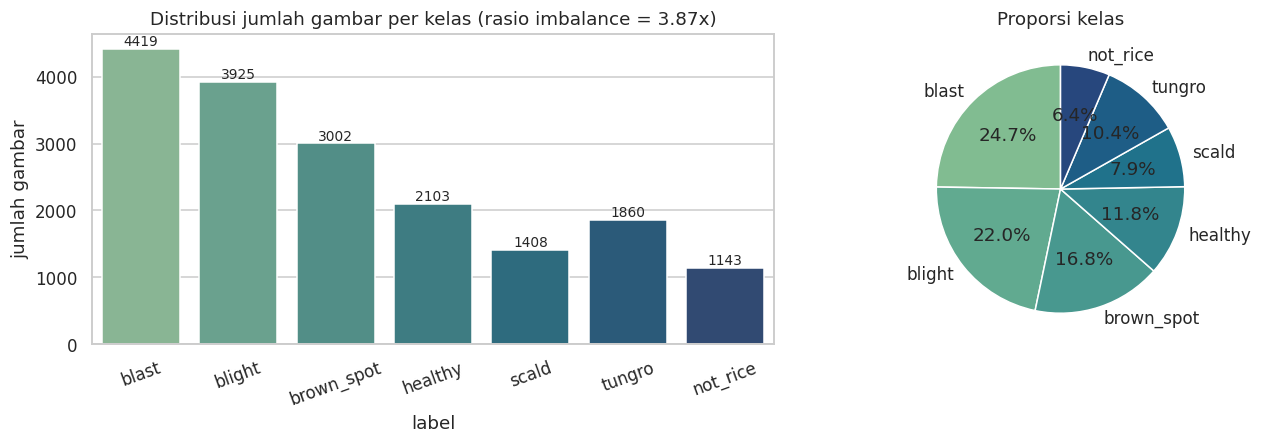

label
blast         4419
blight        3925
brown_spot    3002
healthy       2103
scald         1408
tungro        1860
not_rice      1143

Kelas mayoritas: blast (4419) | minoritas: not_rice (1143)
Rasio imbalance : 3.87x -> perlu penanganan khusus


In [29]:
# Distribusi kelas
counts = df["label"].value_counts().reindex(CLASSES).fillna(0).astype(int)
imbalance_ratio = counts.max() / max(counts.min(), 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
sns.barplot(x=counts.index, y=counts.values, ax=ax[0], palette="crest")
for i, v in enumerate(counts.values):
    ax[0].text(i, v, str(v), ha="center", va="bottom", fontsize=9)
ax[0].set_title(f"Distribusi jumlah gambar per kelas (rasio imbalance = {imbalance_ratio:.2f}x)")
ax[0].set_ylabel("jumlah gambar"); ax[0].tick_params(axis="x", rotation=20)

ax[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
          colors=sns.color_palette("crest", len(counts)))
ax[1].set_title("Proporsi kelas")
plt.tight_layout(); plt.savefig(OUT / "reports/figures/01_class_distribution.png", bbox_inches="tight"); plt.show()

print(counts.to_string())
print(f"\nKelas mayoritas: {counts.idxmax()} ({counts.max()}) | minoritas: {counts.idxmin()} ({counts.min()})")
print(f"Rasio imbalance : {imbalance_ratio:.2f}x -> {'perlu penanganan khusus' if imbalance_ratio > 1.5 else 'relatif seimbang'}")

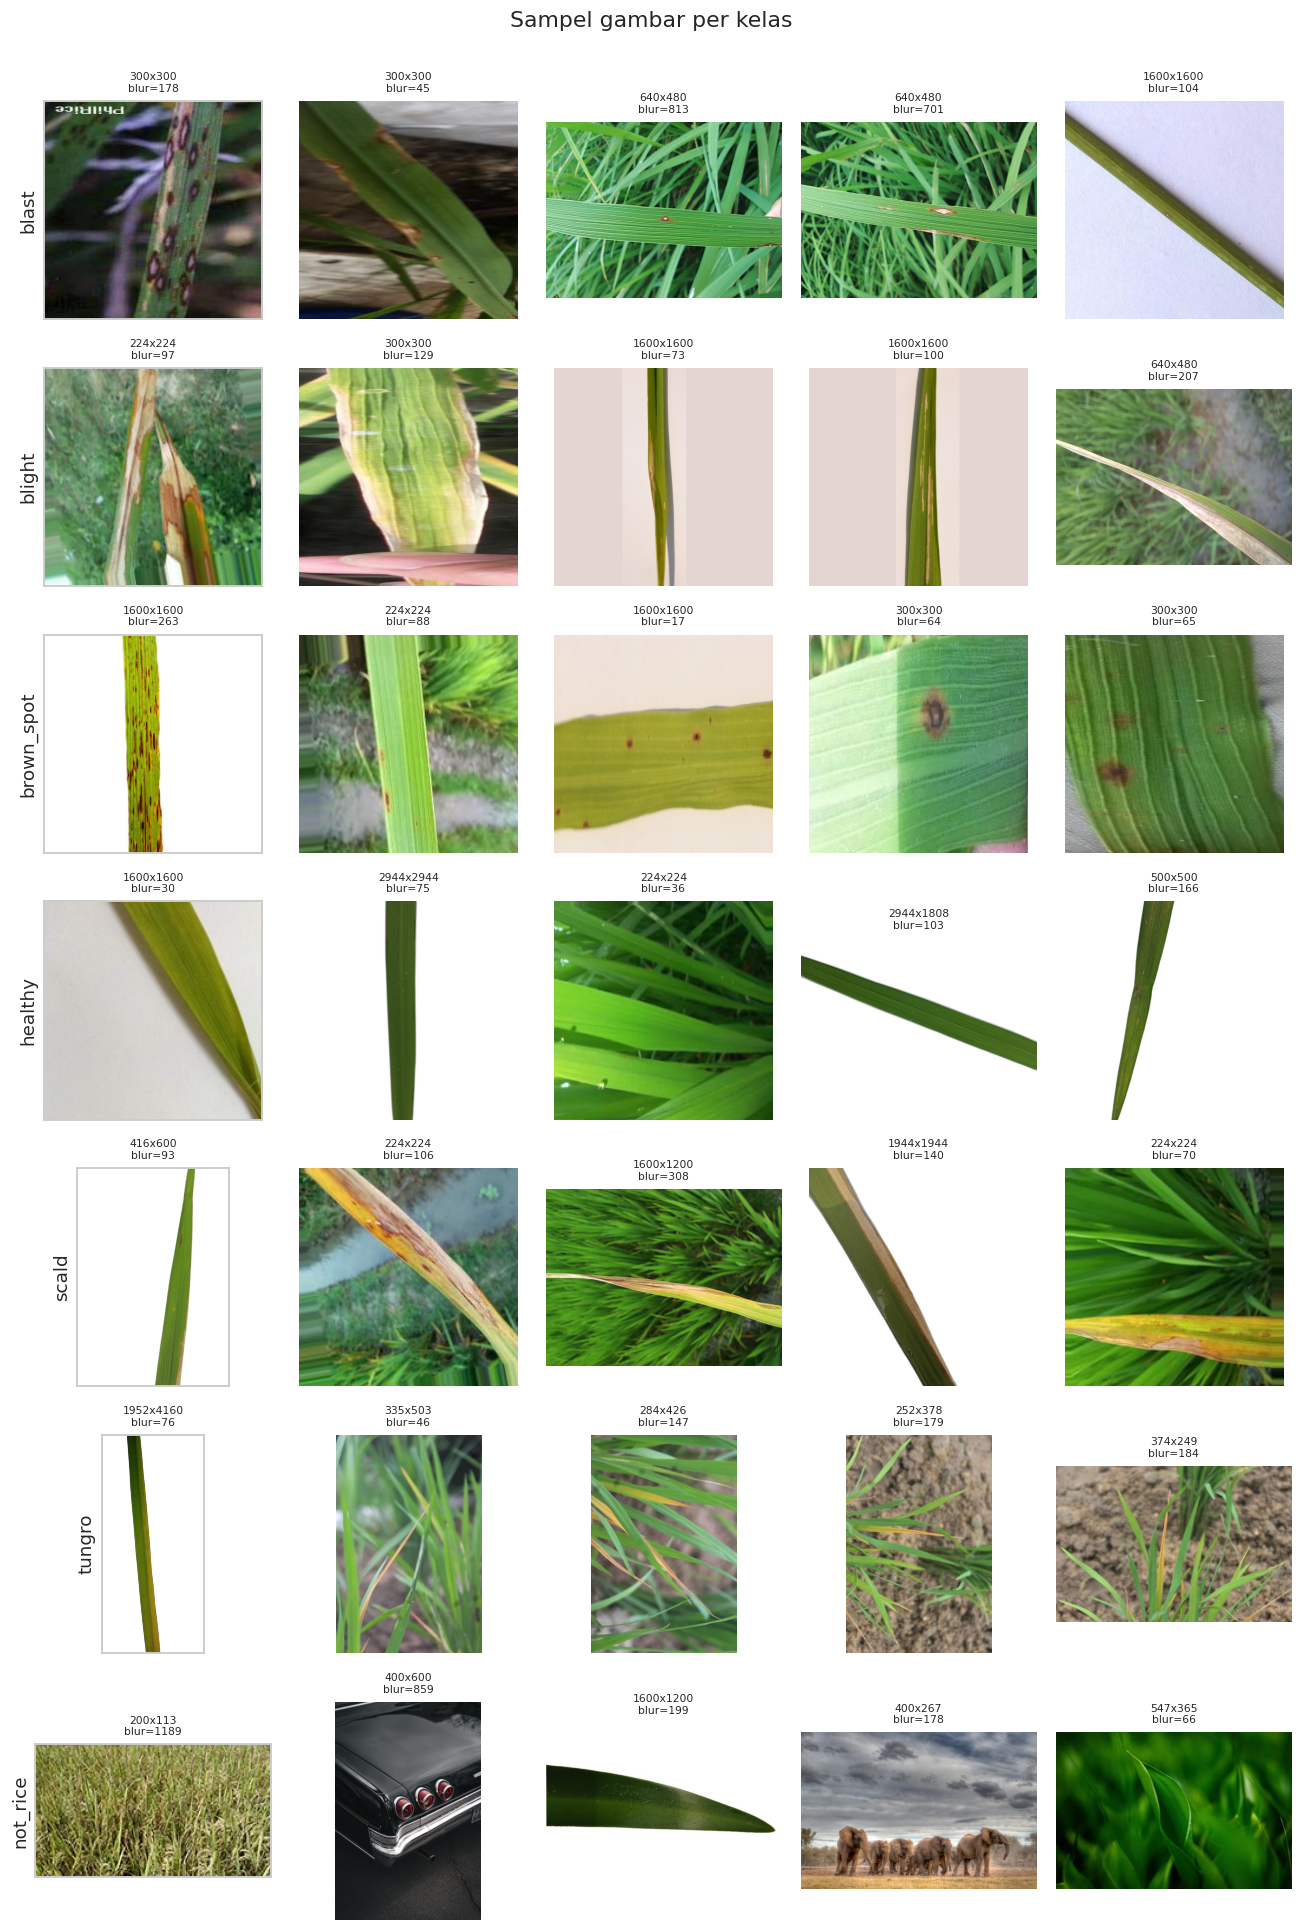

In [ ]:
n_per_class = 5
fig, axes = plt.subplots(NUM_CLASSES, n_per_class, figsize=(n_per_class * 2.4, NUM_CLASSES * 2.5))
for r, cls in enumerate(CLASSES):
    sub = df[df["label"] == cls].sample(min(n_per_class, (df["label"] == cls).sum()), random_state=CONFIG["SEED"])
    for c in range(n_per_class):
        a = axes[r, c]; a.axis("off")
        if c < len(sub):
            row = sub.iloc[c]
            a.imshow(Image.open(row["path"]).convert("RGB"))
            a.set_title(f"{row['width']}x{row['height']}\nblur={row['blur']:.0f}", fontsize=7)
    axes[r, 0].set_ylabel(cls)
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
plt.suptitle("Sampel gambar per kelas", y=1.002)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/02_samples_per_class.png", bbox_inches="tight"); plt.show()

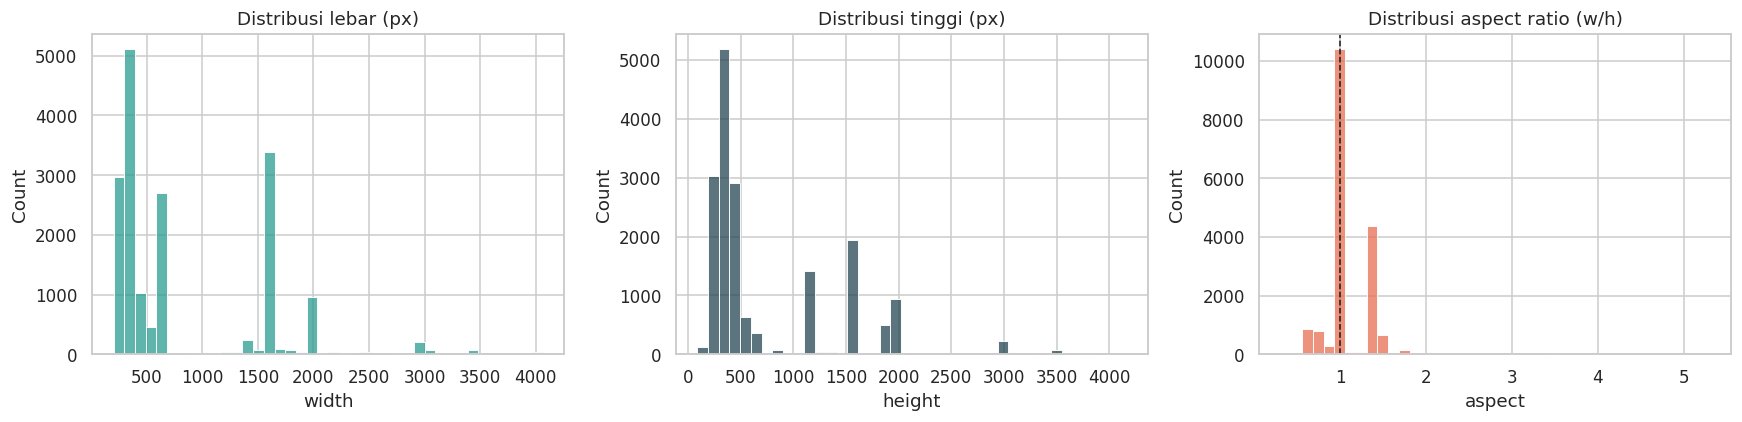

          width    height    aspect
count  17860.00  17860.00  17860.00
mean     815.10    766.74      1.09
std      709.44    692.89      0.27
min      200.00     88.00      0.31
25%      300.00    300.00      1.00
50%      425.00    480.00      1.00
75%     1600.00   1200.00      1.33
max     4064.00   4160.00      5.30

Ukuran paling umum:
 300x300      4624
640x480      2678
224x224      2384
1600x1600    1924
1600x1200    1381
1944x1944     904
400x600       249
500x500       190

Gambar di bawah 224px (akan ter-upscale, berpotensi blur): 377
Mode warna: {'RGB': 17383, 'RGBA': 477}


In [31]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["width"], bins=40, ax=ax[0], color="#2a9d8f"); ax[0].set_title("Distribusi lebar (px)")
sns.histplot(df["height"], bins=40, ax=ax[1], color="#264653"); ax[1].set_title("Distribusi tinggi (px)")
sns.histplot(df["aspect"], bins=40, ax=ax[2], color="#e76f51"); ax[2].set_title("Distribusi aspect ratio (w/h)")
ax[2].axvline(1.0, ls="--", c="k", lw=1)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/03_resolution.png", bbox_inches="tight"); plt.show()

print(df[["width", "height", "aspect"]].describe().round(2).to_string())
print("\nUkuran paling umum:\n",
      (df["width"].astype(str) + "x" + df["height"].astype(str)).value_counts().head(8).to_string())
print("\nGambar di bawah 224px (akan ter-upscale, berpotensi blur):",
      int(((df["width"] < 224) | (df["height"] < 224)).sum()))
print("Mode warna:", df["mode"].value_counts().to_dict())

In [ ]:
# Deteksi duplikat dan near duplicate dengan perceptual hashing
# Hitung jarak Hamming antar pHash secara vektorisasi
# Jarak 0, duplikat identik/near-identik  (dibuang, sisakan 1)
# Jarak, near-duplicate (mis. hasil augmentasi/crop dari foto yang sama)
# Near duplicate tidak selalu dibuang, tapi wajib masuk split yang sama agar tidak leakage

POPCOUNT = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)
def hamming_pairs(hashes: np.ndarray, threshold: int, chunk: int = 512):
    n = len(hashes)
    H = hashes.astype(np.uint64).view(np.uint8).reshape(n, 8)
    pairs = []
    for start in tqdm(range(0, n, chunk), desc="Hamming distance"):
        end = min(start + chunk, n)
        block = POPCOUNT[np.bitwise_xor(H[start:end, None, :], H[None, :, :])].sum(axis=-1)
        idx_i, idx_j = np.where(block <= threshold)
        for a, b in zip(idx_i, idx_j):
            i, j = start + int(a), int(b)
            if i < j:
                pairs.append((i, j, int(block[a, b])))
    return pairs


class UnionFind:
    def __init__(self, n): self.p = list(range(n))
    def find(self, x):
        while self.p[x] != x:
            self.p[x] = self.p[self.p[x]]; x = self.p[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra != rb: self.p[rb] = ra

hashes = df["phash"].to_numpy(dtype=np.uint64)
if len(df) > 30000:
    print("[INFO] Dataset besar; perhitungan O(n^2) bisa lama. Pertimbangkan bucketing/LSH.")

pairs = hamming_pairs(hashes, CONFIG["PHASH_DUP_THRESHOLD"])
exact_pairs = [p for p in pairs if p[2] == 0]
near_pairs  = [p for p in pairs if p[2] > 0]

uf = UnionFind(len(df))
for i, j, _ in pairs:
    uf.union(i, j)
df["group_id"] = [uf.find(i) for i in range(len(df))]

grp_sizes = df["group_id"].value_counts()
print(f"Pasangan duplikat identik (dist=0) : {len(exact_pairs)}")
print(f"Pasangan near-duplicate (0<d<={CONFIG['PHASH_DUP_THRESHOLD']}) : {len(near_pairs)}")
print(f"Jumlah group unik                  : {df['group_id'].nunique()} (dari {len(df)} gambar)")
print(f"Group beranggota >1                : {(grp_sizes > 1).sum()}  | terbesar: {grp_sizes.max()} gambar")

cross = df.groupby("group_id")["label"].nunique()
cross_ids = cross[cross > 1].index.tolist()
print(f"\n[PENTING] Group yang berisi >1 kelas berbeda: {len(cross_ids)}")
if cross_ids:
    print("Contoh (gambar sangat mirip tapi labelnya beda -> perlu dicek manual):")
    display(df[df["group_id"].isin(cross_ids[:3])][["path", "label", "group_id"]])

Hamming distance:   0%|          | 0/35 [00:00<?, ?it/s]

Pasangan duplikat identik (dist=0) : 5751
Pasangan near-duplicate (0<d<=5) : 3271
Jumlah group unik                  : 12913 (dari 17860 gambar)
Group beranggota >1                : 2557  | terbesar: 39 gambar

[PENTING] Group yang berisi >1 kelas berbeda: 113
Contoh (gambar sangat mirip tapi labelnya beda -> perlu dicek manual):


,path,label,group_id
1483,/kaggle/input/datasets/rafidzakiazhari/datafix...,blast,1483
1497,/kaggle/input/datasets/rafidzakiazhari/datafix...,blast,1483
1514,/kaggle/input/datasets/rafidzakiazhari/datafix...,blast,1514
1524,/kaggle/input/datasets/rafidzakiazhari/datafix...,blast,1524
11389,/kaggle/input/datasets/rafidzakiazhari/datafix...,healthy,1514
14765,/kaggle/input/datasets/rafidzakiazhari/datafix...,scald,1524
15960,/kaggle/input/datasets/rafidzakiazhari/datafix...,scald,1483
15966,/kaggle/input/datasets/rafidzakiazhari/datafix...,scald,1483


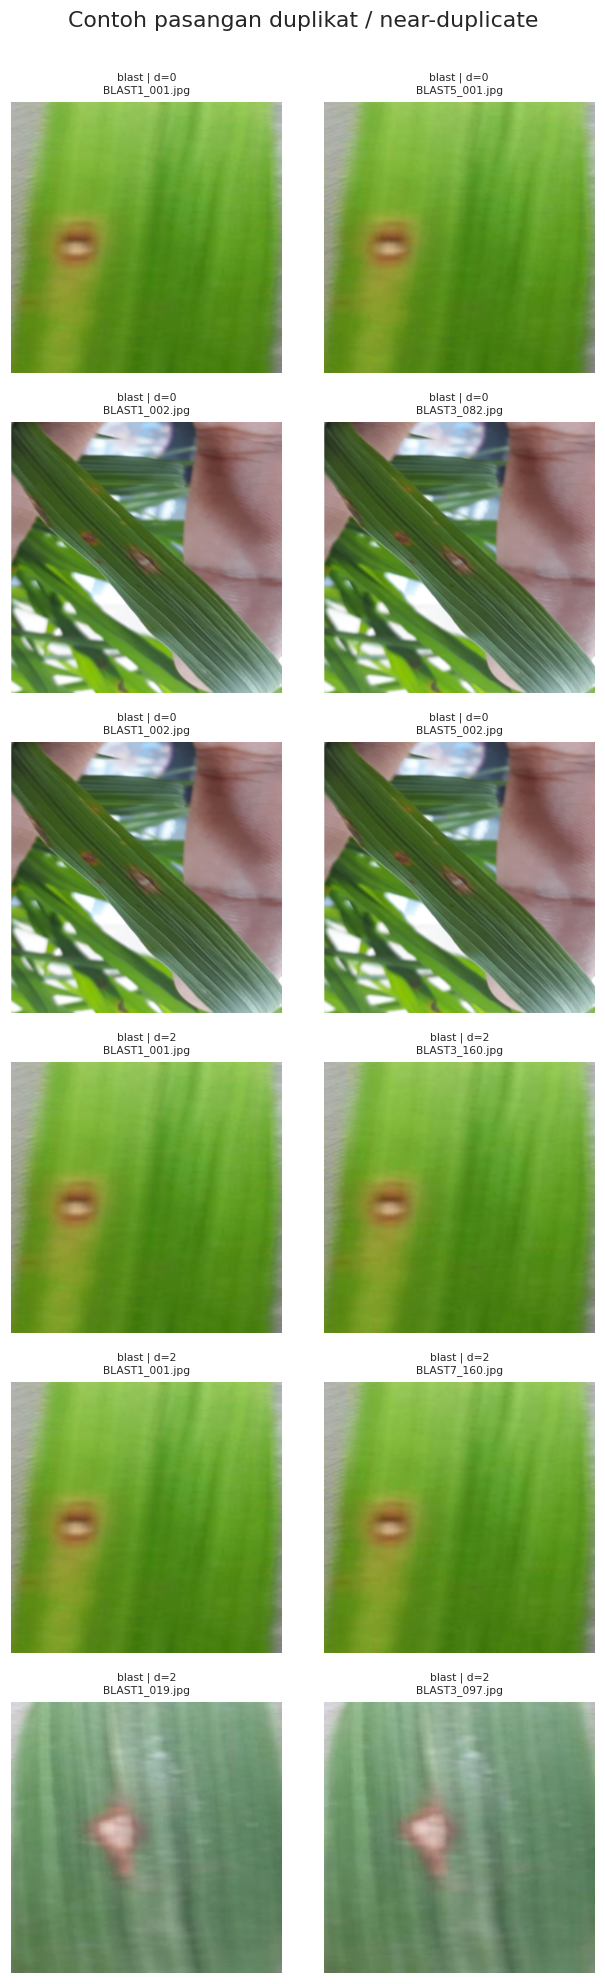

In [33]:
# Visualisasi contoh pasangan duplikat/near duplicate
show = (exact_pairs[:3] + near_pairs[:3])[:6]
if show:
    fig, axes = plt.subplots(len(show), 2, figsize=(6, 3 * len(show)))
    axes = np.atleast_2d(axes)
    for r, (i, j, d) in enumerate(show):
        for c, idx in enumerate([i, j]):
            axes[r, c].imshow(Image.open(df.iloc[idx]["path"]).convert("RGB")); axes[r, c].axis("off")
            axes[r, c].set_title(f"{df.iloc[idx]['label']} | d={d}\n{Path(df.iloc[idx]['path']).name[:26]}", fontsize=7)
    plt.suptitle("Contoh pasangan duplikat / near-duplicate", y=1.001)
    plt.tight_layout(); plt.savefig(OUT / "reports/figures/04_duplicates.png", bbox_inches="tight"); plt.show()
else:
    print("Tidak ditemukan pasangan duplikat pada threshold saat ini.")

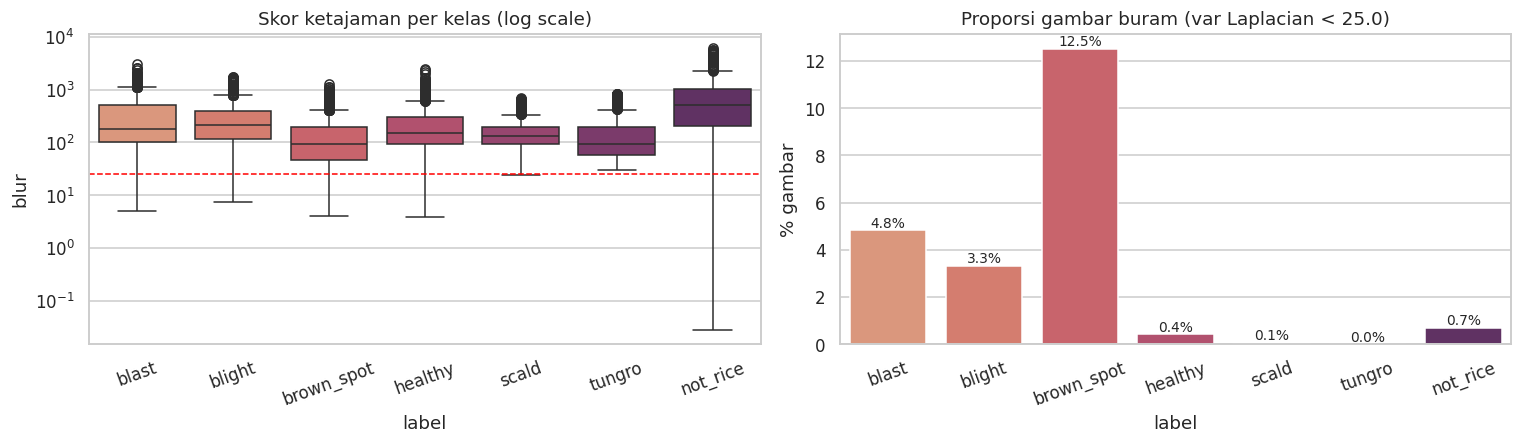

Gambar paling buram:


,path,label,blur,width,height
13807,/kaggle/input/datasets/rafidzakiazhari/datafix...,not_rice,0.027374,300,150
13450,/kaggle/input/datasets/rafidzakiazhari/datafix...,not_rice,0.054688,900,600
13824,/kaggle/input/datasets/rafidzakiazhari/datafix...,not_rice,2.433303,415,739
11976,/kaggle/input/datasets/rafidzakiazhari/datafix...,healthy,3.823196,640,480
10889,/kaggle/input/datasets/rafidzakiazhari/datafix...,brown_spot,4.038394,300,300


In [34]:
# Analisis kualitas gambar dengan Laplacian (semakin kecil semakin buram)
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
sns.boxplot(data=df, x="label", y="blur", ax=ax[0], order=CLASSES, palette="flare")
ax[0].set_yscale("log"); ax[0].set_title("Skor ketajaman per kelas (log scale)")
ax[0].axhline(CONFIG["BLUR_THRESHOLD"], ls="--", c="red", lw=1)
ax[0].tick_params(axis="x", rotation=20)

blur_pct = df.assign(is_blur=df["blur"] < CONFIG["BLUR_THRESHOLD"]).groupby("label")["is_blur"].mean() * 100
blur_pct = blur_pct.reindex(CLASSES).fillna(0)
sns.barplot(x=blur_pct.index, y=blur_pct.values, ax=ax[1], palette="flare")
for i, v in enumerate(blur_pct.values):
    ax[1].text(i, v, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
ax[1].set_title(f"Proporsi gambar buram (var Laplacian < {CONFIG['BLUR_THRESHOLD']})")
ax[1].set_ylabel("% gambar"); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/05_blur.png", bbox_inches="tight"); plt.show()

print("Gambar paling buram:")
display(df.nsmallest(5, "blur")[["path", "label", "blur", "width", "height"]])

In [35]:
# EDA
summary = {
    "total_gambar_valid": int(len(df)),
    "file_corrupt": int(len(corrupt)),
    "jumlah_kelas": int(df["label"].nunique()),
    "distribusi_kelas": counts.to_dict(),
    "rasio_imbalance": round(float(imbalance_ratio), 2),
    "resolusi_median": [int(df["width"].median()), int(df["height"].median())],
    "pasangan_duplikat_identik": len(exact_pairs),
    "pasangan_near_duplicate": len(near_pairs),
    "group_unik": int(df["group_id"].nunique()),
    "persen_gambar_buram": round(float((df["blur"] < CONFIG["BLUR_THRESHOLD"]).mean() * 100), 2),
    "group_lintas_kelas": len(cross_ids),
}
print(json.dumps(summary, indent=2))
json.dump(summary, open(OUT / "reports/eda_summary.json", "w"), indent=2)

{
  "total_gambar_valid": 17860,
  "file_corrupt": 0,
  "jumlah_kelas": 7,
  "distribusi_kelas": {
    "blast": 4419,
    "blight": 3925,
    "brown_spot": 3002,
    "healthy": 2103,
    "scald": 1408,
    "tungro": 1860,
    "not_rice": 1143
  },
  "rasio_imbalance": 3.87,
  "resolusi_median": [
    425,
    480
  ],
  "pasangan_duplikat_identik": 5751,
  "pasangan_near_duplicate": 3271,
  "group_unik": 12913,
  "persen_gambar_buram": 4.13,
  "group_lintas_kelas": 113
}


## 3. Data Cleaning, Split, dan Preprocessing

In [36]:
n_before = len(df)

# Buang duplikat identik: sisakan representatif terbaik per exact hash
df["_rank"] = df["blur"] * 1e-6 + df["width"] * df["height"]
df = (df.sort_values("_rank", ascending=False)
        .drop_duplicates(subset=["phash", "label"], keep="first")
        .drop(columns="_rank")
        .reset_index(drop=True))
print(f"Duplikat identik dibuang : {n_before - len(df)}  -> tersisa {len(df)}")

# Opsional buang near duplicate
if CONFIG["DROP_NEAR_DUP"]:
    n0 = len(df)
    df = df.sort_values("blur", ascending=False).drop_duplicates(subset=["group_id"], keep="first").reset_index(drop=True)
    print(f"Near-duplicate dibuang   : {n0 - len(df)}")

# Opsional buang gambar buram
if CONFIG["DROP_BLUR"]:
    n0 = len(df)
    df = df[df["blur"] >= CONFIG["BLUR_THRESHOLD"]].reset_index(drop=True)
    print(f"Gambar sangat buram dibuang: {n0 - len(df)}")

print("\nDistribusi kelas setelah cleaning:")
print(df["label"].value_counts().reindex(CLASSES).fillna(0).astype(int).to_string())

Duplikat identik dibuang : 3535  -> tersisa 14325

Distribusi kelas setelah cleaning:
label
blast         3440
blight        2849
brown_spot    2092
healthy       1949
scald         1360
tungro        1495
not_rice      1140


Group yang tersebar di >1 split : 0
Verifikasi anti-leakage: LOLOS



split,train,val,test,total
label,,,,
blast,2399,514,527,3440
blight,1993,426,430,2849
brown_spot,1464,314,314,2092
healthy,1369,290,290,1949
scald,963,204,193,1360
tungro,1049,222,224,1495
not_rice,798,171,171,1140



Proporsi aktual: {'train': 0.701, 'test': 0.15, 'val': 0.149}


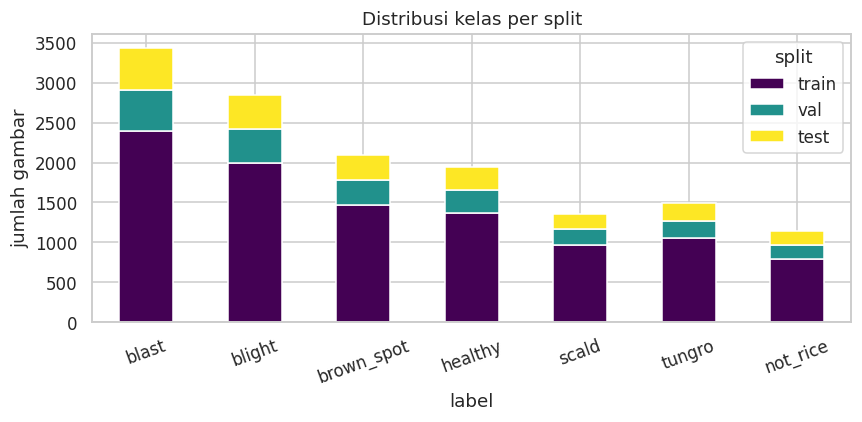

Manifest disimpan -> /kaggle/working/artifacts/reports/dataset_manifest.csv


In [37]:
# Group-aware stratified split agar tidak leakage, setiap group ditugaskan utuh ke satu split alokasi dilakukan, per kelas secara greedy agar proporsi kelas tetap terjaga

def group_stratified_split(frame: pd.DataFrame, ratios=(0.7, 0.15, 0.15), seed=42):
    rng = np.random.RandomState(seed)
    assignment = {}
    for cls in frame["label"].unique():
        sub = frame[frame["label"] == cls]
        groups = sub.groupby("group_id").size().sort_values(ascending=False)
        gids = list(groups.index)
        rng.shuffle(gids)
        gids = sorted(gids, key=lambda g: -groups[g])
        target = np.array(ratios) * len(sub)
        current = np.zeros(3)
        for g in gids:
            size = groups[g]
            deficit = (target - current) / np.maximum(target, 1)
            s = int(np.argmax(deficit))
            current[s] += size
            assignment[g] = ["train", "val", "test"][s]
    return frame["group_id"].map(assignment)


df["split"] = group_stratified_split(df, CONFIG["SPLIT_RATIO"], CONFIG["SEED"])

# satu group tidak boleh muncul di >1 split, agar tidak leakage
leak = df.groupby("group_id")["split"].nunique()
n_leak = int((leak > 1).sum())
print(f"Group yang tersebar di >1 split : {n_leak}")
assert n_leak == 0, "LEAKAGE terdeteksi! Periksa fungsi split."
print("Verifikasi anti-leakage: LOLOS\n")

pivot = (pd.crosstab(df["label"], df["split"])
           .reindex(index=CLASSES, columns=["train", "val", "test"])
           .fillna(0).astype(int))
pivot["total"] = pivot.sum(axis=1)
display(pivot)
print("\nProporsi aktual:", (df["split"].value_counts(normalize=True).round(3)).to_dict())

fig, ax = plt.subplots(figsize=(8, 4))
pivot[["train", "val", "test"]].plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Distribusi kelas per split"); ax.set_ylabel("jumlah gambar"); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/06_split_distribution.png", bbox_inches="tight"); plt.show()

# Manifest disimpan
df.to_csv(OUT / "reports/dataset_manifest.csv", index=False)
print("Manifest disimpan ->", OUT / "reports/dataset_manifest.csv")

In [38]:
IMG = CONFIG["IMG_SIZE"]

train_tf = T.Compose([
    T.RandomResizedCrop(IMG, scale=(0.6, 1.0), ratio=(0.75, 1.333)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomApply([T.RandomRotation(25)], p=0.5),
    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.03),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5))], p=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.15, scale=(0.02, 0.12)),
])

eval_tf = T.Compose([
    T.Resize(int(IMG * 1.15)),
    T.CenterCrop(IMG),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])


class RiceLeafDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None, classes=CLASSES):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform
        self.classes = classes
        self.class_to_idx = {c: i for i, c in enumerate(classes)}
        self.targets = [self.class_to_idx[l] for l in self.frame["label"]]

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        try:
            img = Image.open(row["path"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG, IMG), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, self.targets[i], i


train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

train_ds = RiceLeafDataset(train_df, train_tf)
val_ds   = RiceLeafDataset(val_df,   eval_tf)
test_ds  = RiceLeafDataset(test_df,  eval_tf)

# WeightedRandomSampler
train_counts = np.bincount(train_ds.targets, minlength=NUM_CLASSES).astype(float)
class_weights = 1.0 / np.maximum(train_counts, 1)
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(torch.DoubleTensor(sample_weights), num_samples=len(train_ds), replacement=True) \
          if CONFIG["USE_SAMPLER"] else None

common = dict(num_workers=CONFIG["NUM_WORKERS"], pin_memory=(DEVICE.type == "cuda"), persistent_workers=CONFIG["NUM_WORKERS"] > 0)
train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], sampler=sampler, shuffle=(sampler is None), drop_last=True, **common)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["BATCH_SIZE"] * 2, shuffle=False, **common)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["BATCH_SIZE"] * 2, shuffle=False, **common)

print(f"train: {len(train_ds)} | val: {len(val_ds)} | test: {len(test_ds)}")
print("Jumlah per kelas (train):", dict(zip(CLASSES, train_counts.astype(int))))
print("Sampler aktif:", sampler is not None)

train: 10035 | val: 2141 | test: 2149
Jumlah per kelas (train): {'blast': np.int64(2399), 'blight': np.int64(1993), 'brown_spot': np.int64(1464), 'healthy': np.int64(1369), 'scald': np.int64(963), 'tungro': np.int64(1049), 'not_rice': np.int64(798)}
Sampler aktif: True


Bentuk batch: torch.Size([32, 3, 224, 224]) | range nilai: -2.12 s/d 2.64


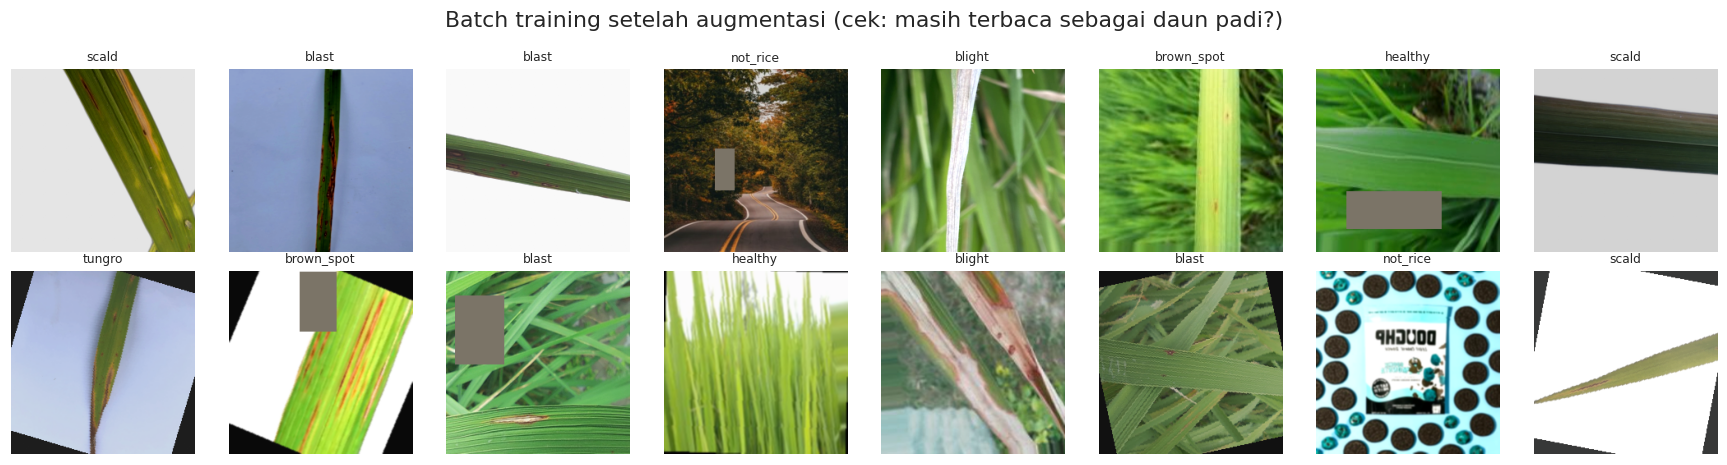

Distribusi kelas pada 10 batch pertama: {'blast': 47, 'blight': 43, 'brown_spot': 51, 'healthy': 37, 'scald': 47, 'tungro': 50, 'not_rice': 45}


In [39]:
# test lihat satu batch training setelah augmentasi
xb, yb, _ = next(iter(train_loader))
print("Bentuk batch:", xb.shape, "| range nilai:", round(xb.min().item(), 2), "s/d", round(xb.max().item(), 2))

inv = lambda t: (t * torch.tensor(STD)[:, None, None] + torch.tensor(MEAN)[:, None, None]).clamp(0, 1)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.3))
for i, a in enumerate(axes.flat):
    if i < len(xb):
        a.imshow(inv(xb[i]).permute(1, 2, 0).numpy()); a.set_title(CLASSES[yb[i]], fontsize=8)
    a.axis("off")
plt.suptitle("Batch training setelah augmentasi (cek: masih terbaca sebagai daun padi?)")
plt.tight_layout(); plt.savefig(OUT / "reports/figures/07_augmented_batch.png", bbox_inches="tight"); plt.show()

# Distribusi kelas dalam beberapa batch membuktikan sampler bekerja
sample_labels = []
for k, (_, y, _) in enumerate(train_loader):
    sample_labels += y.tolist()
    if k >= 9: break
print("Distribusi kelas pada 10 batch pertama:",
      {CLASSES[i]: c for i, c in sorted(Counter(sample_labels).items())})

## 4. Modeling Pemilihan Model Pre Train

In [40]:
def build_model(name=None, num_classes=NUM_CLASSES, pretrained=True):
    name = name or CONFIG["MODEL_NAME"]
    m = timm.create_model(name, pretrained=pretrained, num_classes=num_classes, drop_path_rate=CONFIG["DROP_PATH"])
    return m

model = build_model().to(DEVICE)

# Verifikasi mean/std yang dipakai bobot pretrained
cfg = timm.data.resolve_data_config({}, model=model)
print("Config pretrained timm:", {k: cfg[k] for k in ["input_size", "mean", "std", "crop_pct"] if k in cfg})
if list(cfg["mean"]) != MEAN or list(cfg["std"]) != STD:
    print("[PERHATIAN] mean/std berbeda dari asumsi. Menyesuaikan otomatis.")
    MEAN, STD = list(cfg["mean"]), list(cfg["std"])

n_total = sum(p.numel() for p in model.parameters())
print(f"\nModel      : {CONFIG['MODEL_NAME']}")
print(f"Parameter  : {n_total/1e6:.2f} M  (~{n_total*4/1e6:.0f} MB fp32)")
print("Head       :", model.default_cfg.get("classifier", "head.fc"))

with torch.no_grad():
    out = model(torch.randn(2, 3, IMG, IMG).to(DEVICE))
print("Output shape (sanity check):", tuple(out.shape))

Config pretrained timm: {'input_size': (3, 224, 224), 'mean': (0.485, 0.456, 0.406), 'std': (0.229, 0.224, 0.225), 'crop_pct': 0.875}

Model      : convnextv2_tiny.fcmae_ft_in22k_in1k
Parameter  : 27.87 M  (~111 MB fp32)
Head       : head.fc
Output shape (sanity check): (2, 7)


In [ ]:
# Loss, optimizer, scheduler
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.0):
        super().__init__()
        self.gamma, self.weight, self.ls = gamma, weight, label_smoothing
    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, weight=self.weight,
                             label_smoothing=self.ls, reduction="none")
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()

# Bobot kelas (dipakai hanya bila USE_CLASS_WEIGHTS=True)
w = torch.tensor(len(train_ds) / (NUM_CLASSES * np.maximum(train_counts, 1)),
                 dtype=torch.float32, device=DEVICE)
loss_weight = w if CONFIG["USE_CLASS_WEIGHTS"] else None
if CONFIG["USE_SAMPLER"] and CONFIG["USE_CLASS_WEIGHTS"]:
    print("[PERHATIAN] Sampler + class weights aktif bersamaan = over-correction. Pilih salah satu.")

criterion = (FocalLoss(gamma=2.0, weight=loss_weight, label_smoothing=CONFIG["LABEL_SMOOTHING"])
             if CONFIG["USE_FOCAL"] else
             nn.CrossEntropyLoss(weight=loss_weight, label_smoothing=CONFIG["LABEL_SMOOTHING"]))
print("Loss:", criterion.__class__.__name__, "| class weights:", "ya" if loss_weight is not None else "tidak")

def head_param_names(model):
    clf = model.default_cfg.get("classifier", "head.fc")
    prefix = clf.split(".")[0]
    return [n for n, _ in model.named_parameters() if n.startswith(prefix)]

HEAD_NAMES = set(head_param_names(model))

def set_backbone_trainable(model, flag: bool):
    for n, p in model.named_parameters():
        if n not in HEAD_NAMES:
            p.requires_grad = flag

def trainable_report(model):
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return f"{tr/1e6:.2f}M / {tot/1e6:.2f}M parameter dilatih ({tr/tot*100:.1f}%)"

print("Parameter head:", len(HEAD_NAMES), "tensor")

Loss: CrossEntropyLoss | class weights: tidak
Parameter head: 4 tensor


In [42]:
# Train / evaluasi satu epoch
def run_epoch(model, loader, criterion, optimizer=None, scheduler=None, scaler=None, train=True, accum=1, desc=""):
    model.train(train)
    total_loss, n = 0.0, 0
    ys, ps = [], []
    ctx = contextlib.nullcontext() if train else torch.no_grad()
    with ctx:
        for step, (x, y, _) in enumerate(tqdm(loader, desc=desc, leave=False)):
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            with autocast_ctx():
                logits = model(x)
                loss = criterion(logits, y)
            if train:
                scaler.scale(loss / accum).backward()
                if (step + 1) % accum == 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                    if scheduler is not None:
                        scheduler.step()
            bs = y.size(0)
            total_loss += loss.item() * bs
            n += bs
            ys.append(y.detach().cpu().numpy())
            ps.append(logits.detach().float().argmax(1).cpu().numpy())
    ys, ps = np.concatenate(ys), np.concatenate(ps)
    return {"loss": total_loss / max(n, 1),
            "acc": accuracy_score(ys, ps),
            "f1": f1_score(ys, ps, average="macro", zero_division=0)}


@torch.no_grad()
def predict_probs(model, loader, tta_hflip=False):
    model.eval()
    P, Y, IDX = [], [], []
    for x, y, idx in tqdm(loader, desc="Inference", leave=False):
        x = x.to(DEVICE, non_blocking=True)
        with autocast_ctx():
            p = torch.softmax(model(x).float(), 1)
            if tta_hflip:
                p = (p + torch.softmax(model(torch.flip(x, dims=[3])).float(), 1)) / 2
        P.append(p.cpu().numpy()); Y.append(y.numpy()); IDX.append(idx.numpy())
    return np.concatenate(P), np.concatenate(Y), np.concatenate(IDX)


history = {"epoch": [], "phase": [], "train_loss": [], "train_acc": [], "train_f1": [],
           "val_loss": [], "val_acc": [], "val_f1": [], "lr": []}

def log_epoch(ep, phase, tr, va, lr):
    history["epoch"].append(ep); history["phase"].append(phase); history["lr"].append(lr)
    for k in ["loss", "acc", "f1"]:
        history[f"train_{k}"].append(tr[k]); history[f"val_{k}"].append(va[k])
    print(f"[{phase}] ep {ep:02d} | train loss {tr['loss']:.4f} acc {tr['acc']:.4f} f1 {tr['f1']:.4f} "
          f"|| val loss {va['loss']:.4f} acc {va['acc']:.4f} f1 {va['f1']:.4f} | lr {lr:.2e}")

In [43]:
# Fase 1 head (backbone dibekukan)
CKPT = OUT / "checkpoints/best_model.pth"

set_backbone_trainable(model, False)
print("Fase 1:", trainable_report(model))

opt1 = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=CONFIG["LR_HEAD"], weight_decay=CONFIG["WEIGHT_DECAY"])
sched1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=max(CONFIG["EPOCHS_HEAD"], 1) * len(train_loader))
scaler = make_scaler()

t_start = time.time()
for ep in range(1, CONFIG["EPOCHS_HEAD"] + 1):
    tr = run_epoch(model, train_loader, criterion, opt1, sched1, scaler, train=True, accum=CONFIG["GRAD_ACCUM"], desc=f"P1 train ep{ep}")
    va = run_epoch(model, val_loader, criterion, train=False, desc=f"P1 val ep{ep}")
    log_epoch(ep, "head", tr, va, opt1.param_groups[0]["lr"])
print(f"Fase 1 selesai dalam {(time.time()-t_start)/60:.1f} menit")

Fase 1: 0.01M / 27.87M parameter dilatih (0.0%)


P1 train ep1:   0%|          | 0/313 [00:00<?, ?it/s]

P1 val ep1:   0%|          | 0/34 [00:00<?, ?it/s]

[head] ep 01 | train loss 0.8643 acc 0.7563 f1 0.7558 || val loss 0.6767 acc 0.8421 f1 0.8529 | lr 7.50e-04


P1 train ep2:   0%|          | 0/313 [00:00<?, ?it/s]

P1 val ep2:   0%|          | 0/34 [00:00<?, ?it/s]

[head] ep 02 | train loss 0.6667 acc 0.8421 f1 0.8395 || val loss 0.6026 acc 0.8748 f1 0.8829 | lr 2.50e-04


P1 train ep3:   0%|          | 0/313 [00:00<?, ?it/s]

P1 val ep3:   0%|          | 0/34 [00:00<?, ?it/s]

[head] ep 03 | train loss 0.6450 acc 0.8524 f1 0.8518 || val loss 0.6020 acc 0.8744 f1 0.8822 | lr 0.00e+00
Fase 1 selesai dalam 7.4 menit


In [44]:
# Fase 2 Fine tune penuh + discriminative LR + OneCycleLR + early stopping + checkpoint terbaik dari macro f1
set_backbone_trainable(model, True)
print("Fase 2:", trainable_report(model))

backbone_params = [p for n, p in model.named_parameters() if n not in HEAD_NAMES]
head_params     = [p for n, p in model.named_parameters() if n in HEAD_NAMES]

opt2 = torch.optim.AdamW(
    [{"params": backbone_params, "lr": CONFIG["LR_BACKBONE"]},
     {"params": head_params,     "lr": CONFIG["LR_HEAD"]}],
    weight_decay=CONFIG["WEIGHT_DECAY"])

steps_per_epoch = max(len(train_loader) // CONFIG["GRAD_ACCUM"], 1)
sched2 = torch.optim.lr_scheduler.OneCycleLR(
    opt2, max_lr=[CONFIG["LR_BACKBONE"], CONFIG["LR_HEAD"]],
    steps_per_epoch=steps_per_epoch, epochs=CONFIG["EPOCHS_FULL"],
    pct_start=0.1, div_factor=10, final_div_factor=100)

best_f1, best_epoch, patience = -1.0, -1, 0
t_start = time.time()

for ep in range(1, CONFIG["EPOCHS_FULL"] + 1):
    tr = run_epoch(model, train_loader, criterion, opt2, sched2, scaler, train=True,
                   accum=CONFIG["GRAD_ACCUM"], desc=f"P2 train ep{ep}")
    va = run_epoch(model, val_loader, criterion, train=False, desc=f"P2 val ep{ep}")
    log_epoch(CONFIG["EPOCHS_HEAD"] + ep, "full", tr, va, opt2.param_groups[0]["lr"])

    if va["f1"] > best_f1:
        best_f1, best_epoch, patience = va["f1"], ep, 0
        torch.save({"state_dict": model.state_dict(),
                    "model_name": CONFIG["MODEL_NAME"],
                    "classes": CLASSES, "img_size": IMG, "mean": MEAN, "std": STD,
                    "val_f1": best_f1, "val_acc": va["acc"], "epoch": ep,
                    "config": CONFIG}, CKPT)
        print(f"   -> checkpoint disimpan (val macro-F1 {best_f1:.4f})")
    else:
        patience += 1
        if patience >= CONFIG["PATIENCE"]:
            print(f"Early stopping di epoch {ep} (tidak ada perbaikan {CONFIG['PATIENCE']} epoch)")
            break

print(f"\nFase 2 selesai dalam {(time.time()-t_start)/60:.1f} menit")
print(f"Val macro-F1 terbaik: {best_f1:.4f} (epoch {best_epoch})")
pd.DataFrame(history).to_csv(OUT / "reports/training_history.csv", index=False)

Fase 2: 27.87M / 27.87M parameter dilatih (100.0%)


P2 train ep1:   0%|          | 0/313 [00:00<?, ?it/s]

P2 val ep1:   0%|          | 0/34 [00:00<?, ?it/s]

[full] ep 04 | train loss 0.5722 acc 0.8881 f1 0.8877 || val loss 0.5543 acc 0.8898 f1 0.8965 | lr 6.30e-05
   -> checkpoint disimpan (val macro-F1 0.8965)


P2 train ep2:   0%|          | 0/313 [00:00<?, ?it/s]

...

P2 val ep17:   0%|          | 0/34 [00:00<?, ?it/s]

[full] ep 20 | train loss 0.2821 acc 0.9896 f1 0.9896 || val loss 0.3352 acc 0.9706 f1 0.9695 | lr 1.03e-06


P2 train ep18:   0%|          | 0/313 [00:00<?, ?it/s]

P2 val ep18:   0%|          | 0/34 [00:00<?, ?it/s]

[full] ep 21 | train loss 0.2852 acc 0.9879 f1 0.9879 || val loss 0.3348 acc 0.9710 f1 0.9702 | lr 1.00e-07
   -> checkpoint disimpan (val macro-F1 0.9702)

Fase 2 selesai dalam 48.2 menit
Val macro-F1 terbaik: 0.9702 (epoch 18)


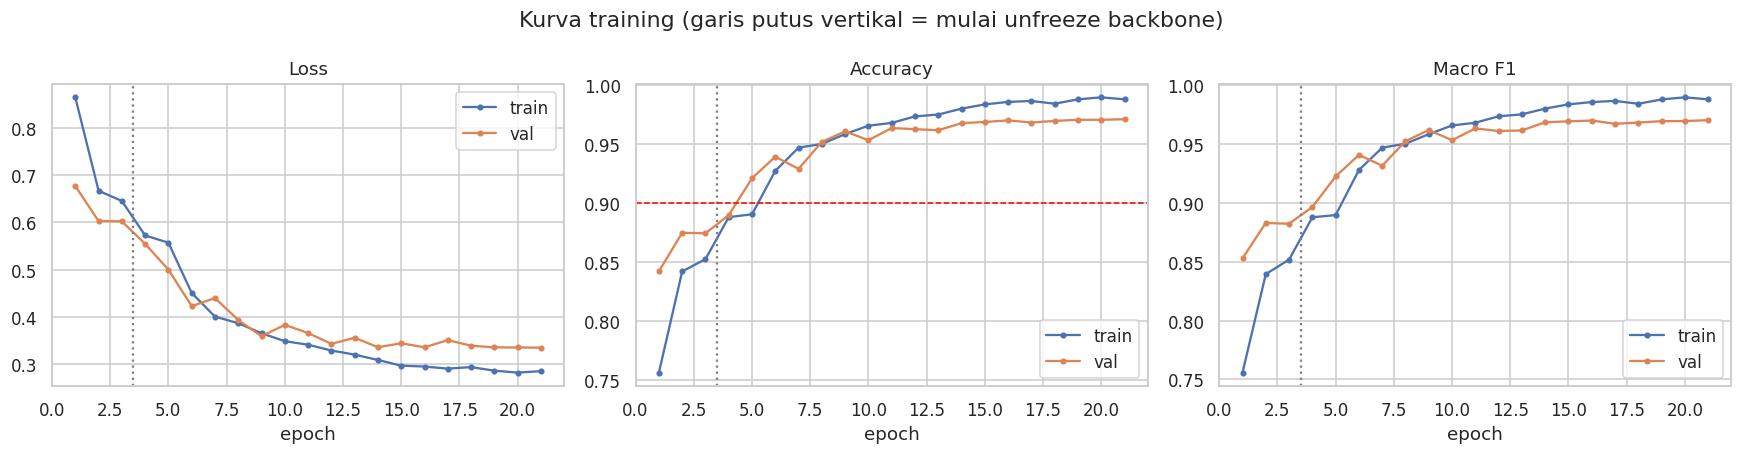

Gap train-val accuracy pada epoch terakhir: 0.017 -> wajar


In [45]:
# Kurva training/validation
h = pd.DataFrame(history)
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(h["epoch"], h["train_loss"], "-o", ms=3, label="train")
ax[0].plot(h["epoch"], h["val_loss"], "-o", ms=3, label="val"); ax[0].set_title("Loss")
ax[1].plot(h["epoch"], h["train_acc"], "-o", ms=3, label="train")
ax[1].plot(h["epoch"], h["val_acc"], "-o", ms=3, label="val"); ax[1].set_title("Accuracy")
ax[2].plot(h["epoch"], h["train_f1"], "-o", ms=3, label="train")
ax[2].plot(h["epoch"], h["val_f1"], "-o", ms=3, label="val"); ax[2].set_title("Macro F1")
for a in ax:
    a.axvline(CONFIG["EPOCHS_HEAD"] + 0.5, ls=":", c="gray")
    a.set_xlabel("epoch"); a.legend()
ax[1].axhline(CONFIG["TARGET_ACC"], ls="--", c="red", lw=1)
plt.suptitle("Kurva training (garis putus vertikal = mulai unfreeze backbone)")
plt.tight_layout(); plt.savefig(OUT / "reports/figures/08_training_curves.png", bbox_inches="tight"); plt.show()

gap = h["train_acc"].iloc[-1] - h["val_acc"].iloc[-1]
print(f"Gap train-val accuracy pada epoch terakhir: {gap:.3f}",
      "-> indikasi overfitting, pertimbangkan augmentasi lebih kuat / drop_path lebih besar" if gap > 0.10 else "-> wajar")

## 5. Evaluasi

In [46]:
# Dari checkpoint terbaik
ckpt = torch.load(CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["state_dict"])
model.eval()
print(f"Checkpoint dimuat: epoch {ckpt['epoch']} | val macro-F1 {ckpt['val_f1']:.4f}")

probs, y_true, idxs = predict_probs(model, test_loader, tta_hflip=CONFIG["TTA_HFLIP"])
y_pred = probs.argmax(1)
conf   = probs.max(1)

metrics = {
    "accuracy":        float(accuracy_score(y_true, y_pred)),
    "macro_f1":        float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
    "macro_recall":    float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
    "weighted_f1":     float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
    "n_test":          int(len(y_true)),
    "tta_hflip":       bool(CONFIG["TTA_HFLIP"]),
}
print("\n=== HASIL TEST SET ===")
for k, v in metrics.items():
    print(f"{k:17s}: {v:.4f}" if isinstance(v, float) else f"{k:17s}: {v}")

target = CONFIG["TARGET_ACC"]
print(f"\nTarget >{target*100:.0f}% : accuracy {'TERCAPAI' if metrics['accuracy'] >= target else 'BELUM'} | "
      f"macro-F1 {'TERCAPAI' if metrics['macro_f1'] >= target else 'BELUM'}")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4, zero_division=0))

rep = pd.DataFrame(classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True, zero_division=0)).T
rep.to_csv(OUT / "reports/classification_report.csv")
json.dump(metrics, open(OUT / "reports/test_metrics.json", "w"), indent=2)

Checkpoint dimuat: epoch 18 | val macro-F1 0.9702


Inference:   0%|          | 0/34 [00:00<?, ?it/s]


=== HASIL TEST SET ===
accuracy         : 0.9767
macro_f1         : 0.9762
macro_precision  : 0.9778
macro_recall     : 0.9748
weighted_f1      : 0.9767
n_test           : 2149
tta_hflip        : True

Target >90% : accuracy TERCAPAI | macro-F1 TERCAPAI

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

       blast     0.9629    0.9848    0.9737       527
      blight     1.0000    0.9953    0.9977       430
  brown_spot     0.9776    0.9745    0.9761       314
     healthy     0.9582    0.9483    0.9532       290
       scald     0.9645    0.9845    0.9744       193
      tungro     0.9814    0.9420    0.9613       224
    not_rice     1.0000    0.9942    0.9971       171

    accuracy                         0.9767      2149
   macro avg     0.9778    0.9748    0.9762      2149
weighted avg     0.9769    0.9767    0.9767      2149



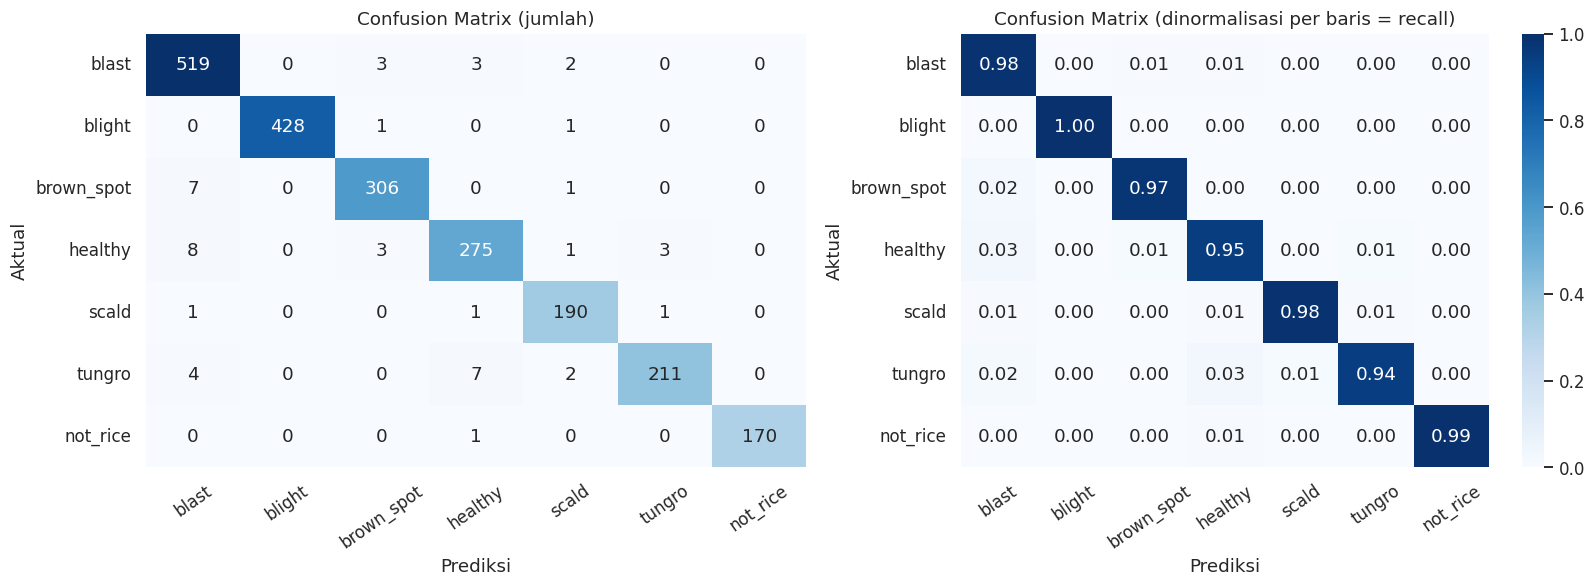

Recall per kelas: {'blast': 0.985, 'blight': 0.995, 'brown_spot': 0.975, 'healthy': 0.948, 'scald': 0.984, 'tungro': 0.942, 'not_rice': 0.994}


In [47]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
cmn = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[0], cbar=False)
ax[0].set_title("Confusion Matrix (jumlah)"); ax[0].set_xlabel("Prediksi"); ax[0].set_ylabel("Aktual")
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax[1], vmin=0, vmax=1)
ax[1].set_title("Confusion Matrix (dinormalisasi per baris = recall)")
ax[1].set_xlabel("Prediksi"); ax[1].set_ylabel("Aktual")
for a in ax:
    a.tick_params(axis="x", rotation=35); a.tick_params(axis="y", rotation=0)
plt.tight_layout(); plt.savefig(OUT / "reports/figures/09_confusion_matrix.png", bbox_inches="tight"); plt.show()

print("Recall per kelas:", {CLASSES[i]: round(float(cmn[i, i]), 3) for i in range(NUM_CLASSES)})

In [48]:
# Analisis error: kelas mana yang tertukar
err_mask = y_pred != y_true
test_eval = test_df.iloc[idxs].reset_index(drop=True)
test_eval["y_true"]  = [CLASSES[i] for i in y_true]
test_eval["y_pred"]  = [CLASSES[i] for i in y_pred]
test_eval["conf"]    = conf
test_eval["correct"] = ~err_mask
test_eval.to_csv(OUT / "reports/test_predictions.csv", index=False)

print(f"Total salah klasifikasi: {int(err_mask.sum())} dari {len(y_true)} ({err_mask.mean()*100:.2f}%)\n")

pairs_err = Counter((CLASSES[t], CLASSES[p]) for t, p in zip(y_true[err_mask], y_pred[err_mask]))
print("Pasangan paling sering tertukar (aktual -> prediksi):")
for (t, p), c in pairs_err.most_common(8):
    print(f"  {t:11s} -> {p:11s} : {c}")

# Apakah error berkorelasi dengan kualitas gambar
print("\nPerbandingan karakteristik gambar benar vs salah:")
display(test_eval.groupby("correct")[["blur", "width", "height", "conf"]].agg(["mean", "median"]).round(2))
print("\nRata-rata confidence: benar = %.3f | salah = %.3f" %
      (test_eval[test_eval.correct]["conf"].mean(), test_eval[~test_eval.correct]["conf"].mean()))

Total salah klasifikasi: 50 dari 2149 (2.33%)

Pasangan paling sering tertukar (aktual -> prediksi):
  healthy     -> blast       : 8
  tungro      -> healthy     : 7
  brown_spot  -> blast       : 7
  tungro      -> blast       : 4
  blast       -> healthy     : 3
  healthy     -> tungro      : 3
  blast       -> brown_spot  : 3
  healthy     -> brown_spot  : 3

Perbandingan karakteristik gambar benar vs salah:


blur            width           height          conf       
           mean  median     mean  median     mean  median  mean median
correct                                                               
False    180.04  128.78  1669.70  1600.0  1504.12  1600.0  0.81   0.90
True     304.29  168.52   880.46   640.0   827.94   480.0  0.95   0.96


Rata-rata confidence: benar = 0.953 | salah = 0.808


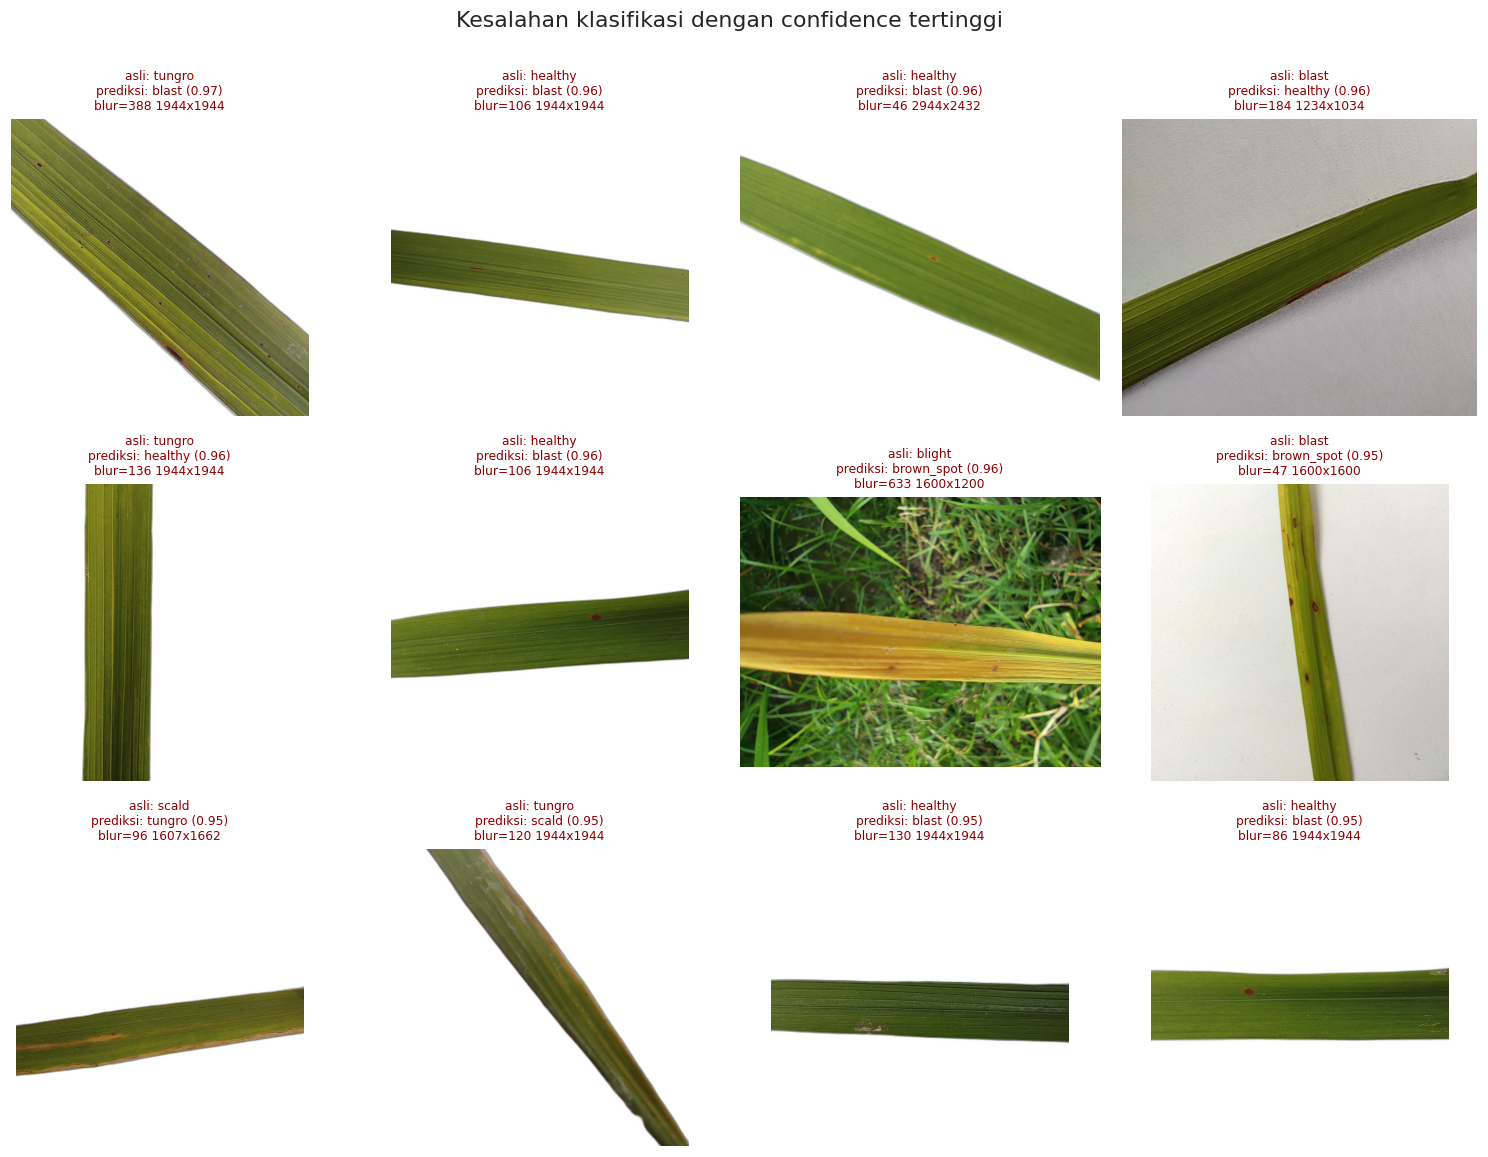

In [49]:
# Contoh gambar yang salah diklasifikasi
wrong = test_eval[~test_eval["correct"]].sort_values("conf", ascending=False)
n_show = min(12, len(wrong))
if n_show:
    fig, axes = plt.subplots(3, 4, figsize=(14, 10.5))
    for i, a in enumerate(axes.flat):
        a.axis("off")
        if i < n_show:
            r = wrong.iloc[i]
            a.imshow(Image.open(r["path"]).convert("RGB"))
            a.set_title(f"asli: {r['y_true']}\nprediksi: {r['y_pred']} ({r['conf']:.2f})\nblur={r['blur']:.0f} {r['width']}x{r['height']}",
                        fontsize=8, color="darkred")
    plt.suptitle("Kesalahan klasifikasi dengan confidence tertinggi", y=1.0)
    plt.tight_layout(); plt.savefig(OUT / "reports/figures/10_misclassified.png", bbox_inches="tight"); plt.show()
else:
    print("Tidak ada kesalahan klasifikasi pada test set")

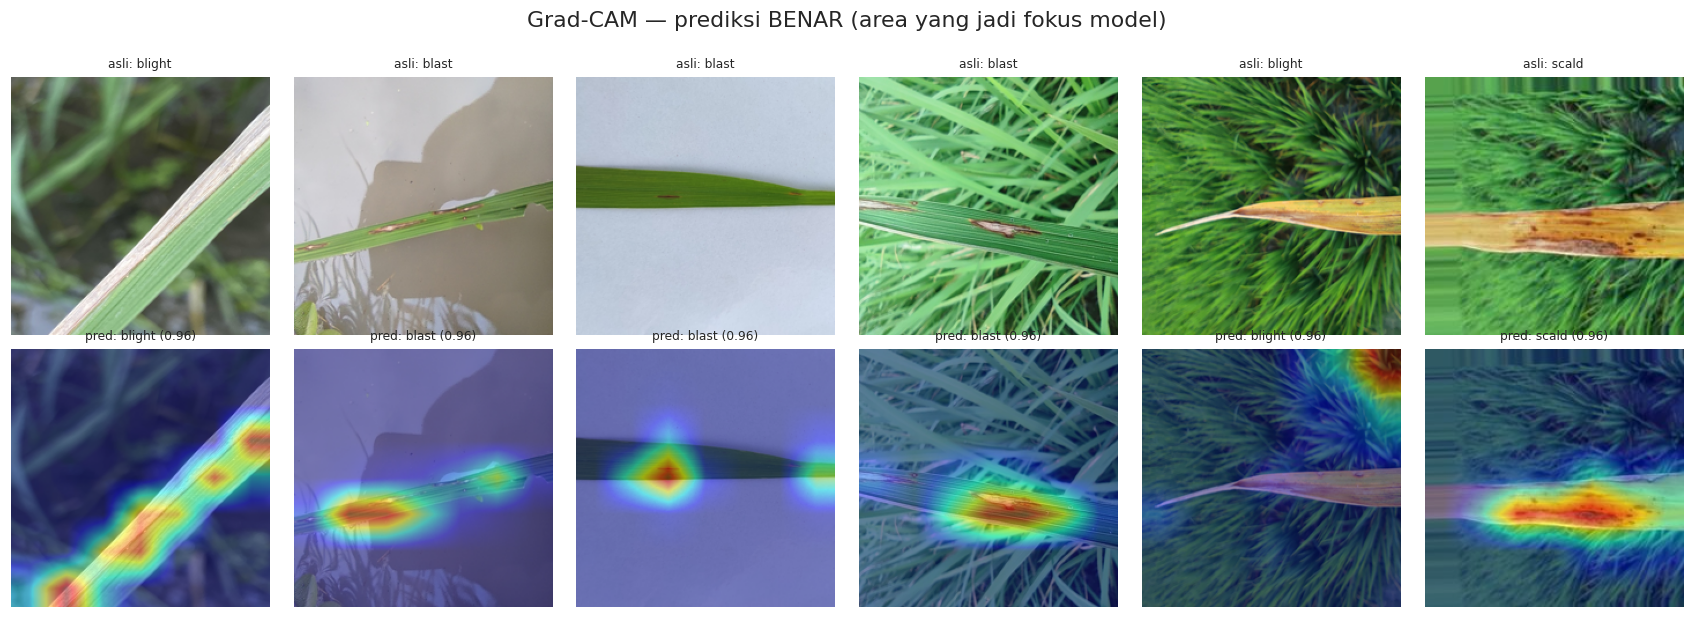

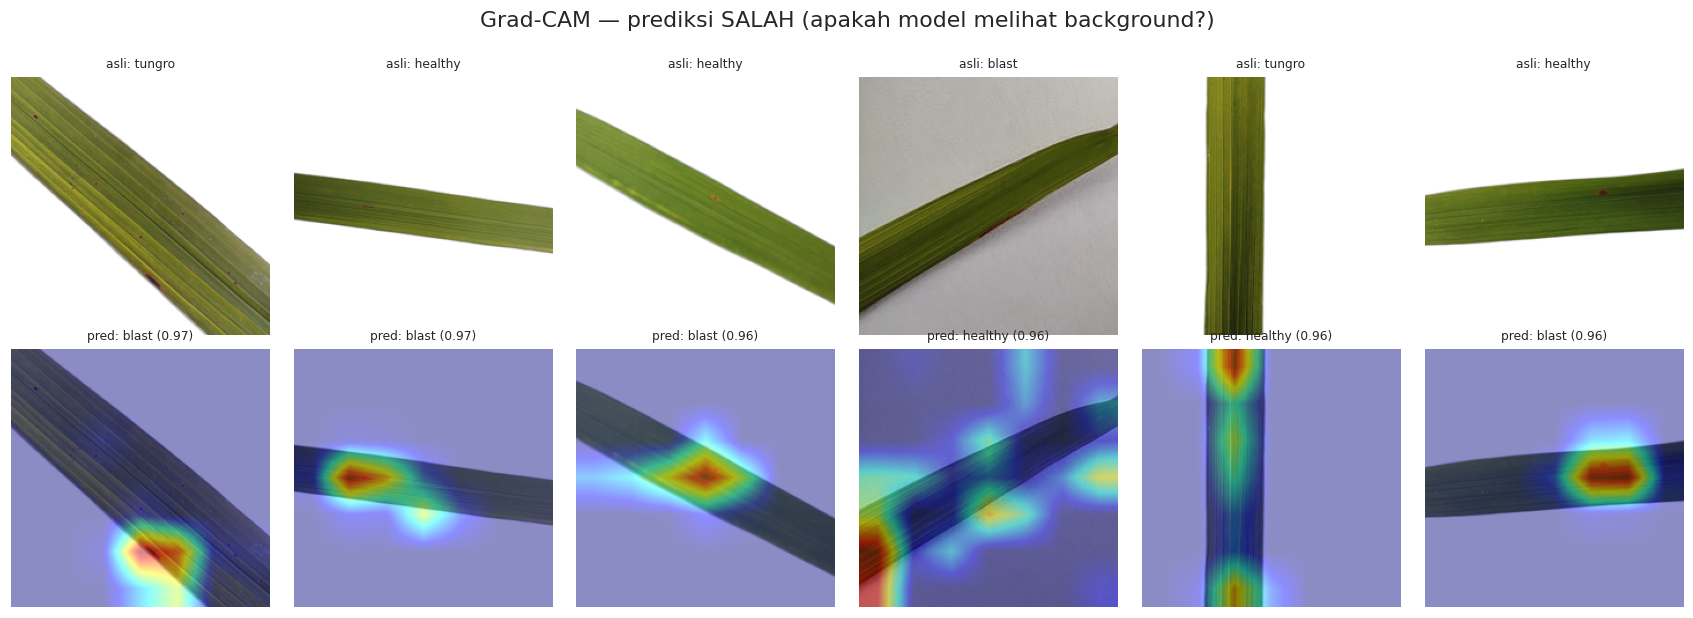

In [50]:
# Grad-CAM, implementasi manual dengan hook,
def get_cam_layer(m):
    if hasattr(m, "stages"):   return m.stages[-1]
    if hasattr(m, "blocks"):   return m.blocks[-1]
    raise ValueError("Tentukan target layer secara manual untuk arsitektur ini.")

def grad_cam(model, x, class_idx=None):
    model.eval()
    store = {}
    layer = get_cam_layer(model)
    h = layer.register_forward_hook(lambda m, i, o: store.__setitem__("act", o))
    try:
        x = x.to(DEVICE).requires_grad_(False)
        logits = model(x)
        if class_idx is None:
            class_idx = logits.argmax(1)
        score = logits.gather(1, class_idx.view(-1, 1)).sum()
        act = store["act"]
        grads = torch.autograd.grad(score, act)[0]  
        weights = grads.mean(dim=(2, 3), keepdim=True)  
        cam = F.relu((weights * act).sum(1)) 
        cam = cam - cam.amin(dim=(1, 2), keepdim=True)
        cam = cam / (cam.amax(dim=(1, 2), keepdim=True) + 1e-8)
        return cam.detach().cpu().numpy(), class_idx.detach().cpu().numpy(), torch.softmax(logits, 1).detach().cpu().numpy()
    finally:
        h.remove()


def show_gradcam(rows, title, fname):
    n = len(rows)
    if n == 0:
        print("Tidak ada gambar untuk ditampilkan."); return
    fig, axes = plt.subplots(2, n, figsize=(2.6 * n, 5.6))
    axes = np.atleast_2d(axes)
    for c, (_, r) in enumerate(rows.iterrows()):
        pil = Image.open(r["path"]).convert("RGB")
        x = eval_tf(pil).unsqueeze(0)
        cam, cls, pr = grad_cam(model, x)
        base = np.asarray(pil.resize((IMG, IMG)))
        heat = cv2.applyColorMap(np.uint8(255 * cv2.resize(cam[0], (IMG, IMG))), cv2.COLORMAP_JET)[:, :, ::-1]
        overlay = np.uint8(0.55 * base + 0.45 * heat)
        axes[0, c].imshow(base); axes[0, c].set_title(f"asli: {r['y_true']}", fontsize=8)
        axes[1, c].imshow(overlay); axes[1, c].set_title(f"pred: {CLASSES[int(cls[0])]} ({pr[0].max():.2f})", fontsize=8)
        axes[0, c].axis("off"); axes[1, c].axis("off")
    plt.suptitle(title, y=1.0)
    plt.tight_layout(); plt.savefig(OUT / f"reports/figures/{fname}", bbox_inches="tight"); plt.show()


correct_rows = test_eval[test_eval["correct"]].sample(min(6, int(test_eval["correct"].sum())), random_state=CONFIG["SEED"])
show_gradcam(correct_rows, "Grad-CAM — prediksi BENAR (area yang jadi fokus model)", "11_gradcam_correct.png")
if len(wrong):
    show_gradcam(wrong.head(min(6, len(wrong))), "Grad-CAM — prediksi SALAH (apakah model melihat background?)", "12_gradcam_wrong.png")

In [51]:
# Iterative Improvement saran otomatis berdasarkan hasil aktual
acc, mf1 = metrics["accuracy"], metrics["macro_f1"]
per_class_f1 = {CLASSES[i]: float(f1_score(y_true == i, y_pred == i, zero_division=0)) for i in range(NUM_CLASSES)}
weakest = min(per_class_f1, key=per_class_f1.get)

print("F1 per kelas:", {k: round(v, 3) for k, v in per_class_f1.items()})
print(f"Kelas terlemah: {weakest} (F1 {per_class_f1[weakest]:.3f})\n")

F1 per kelas: {'blast': 0.974, 'blight': 0.998, 'brown_spot': 0.976, 'healthy': 0.953, 'scald': 0.974, 'tungro': 0.961, 'not_rice': 0.997}
Kelas terlemah: healthy (F1 0.953)



## 6. Export Model

In [52]:
DEPLOY = OUT / "deploy"
DEPLOY.mkdir(parents=True, exist_ok=True)

# Model bersih untuk inference: tanpa drop_path, di CPU, mode eval
export_model = timm.create_model(CONFIG["MODEL_NAME"], pretrained=False, num_classes=NUM_CLASSES, drop_path_rate=0.0)
export_model.load_state_dict(ckpt["state_dict"])
export_model.eval().cpu()


class DeployWrapper(nn.Module):
    # Input : (B,3,H,W) float32 RGB dengan nilai 0..1
    # Output: (B,num_classes) probabilitas (softmax sudah di dalam graph)
    def __init__(self, model, mean, std):
        super().__init__()
        self.model = model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return torch.softmax(self.model((x - self.mean) / self.std), dim=1)


wrapped = DeployWrapper(export_model, MEAN, STD).eval()
dummy = torch.randn(1, 3, IMG, IMG)

# state_dict PyTorch
torch.save({"state_dict": export_model.state_dict(), "model_name": CONFIG["MODEL_NAME"],
            "classes": CLASSES, "img_size": IMG, "mean": MEAN, "std": STD,
            "test_metrics": metrics}, DEPLOY / "model_state_dict.pth")

# TorchScript
with torch.no_grad():
    ts = torch.jit.trace(export_model, dummy)
    ts = torch.jit.freeze(ts.eval())
ts.save(str(DEPLOY / "model_torchscript.pt"))
with torch.no_grad():
    diff = (ts(dummy) - export_model(dummy)).abs().max().item()
print(f"TorchScript OK | selisih maks vs PyTorch: {diff:.2e}")

TorchScript OK | selisih maks vs PyTorch: 0.00e+00


In [ ]:
# Export ONNX
import subprocess

onnx_backend = DEPLOY / "model.onnx"        # input ternormalisasi -> logits
onnx_web     = DEPLOY / "model_web.onnx"    # input 0..1 -> probabilitas

def _ensure_onnxscript():
    try:
        import onnxscript
        return True
    except ImportError:
        print("   menginstal onnxscript ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "onnxscript"])
        try:
            import onnxscript
            return True
        except ImportError:
            return False


def export_onnx(module, path, out_name):
    kwargs = dict(input_names=["input"], output_names=[out_name],
                  dynamic_axes={"input": {0: "batch"}, out_name: {0: "batch"}},
                  opset_version=17, do_constant_folding=True)
    try:
        torch.onnx.export(module, dummy, str(path), dynamo=False, **kwargs)
        print(f"{path.name}: OK (exporter TorchScript, dynamo=False)")
        return path
    except TypeError:
        torch.onnx.export(module, dummy, str(path), **kwargs)
        print(f"{path.name}: OK (exporter legacy)")
        return path
    except Exception as e:
        print(f"{path.name}: exporter lama gagal ({type(e).__name__}), beralih ke exporter dynamo ...")

    assert _ensure_onnxscript(), "onnxscript gagal dipasang. Aktifkan Internet di Settings Kaggle lalu ulangi."
    torch.onnx.export(module, (dummy,), str(path), dynamo=True, **kwargs)
    print(f"{path.name}: OK (exporter dynamo)")
    return path


export_onnx(export_model, onnx_backend, "logits")
export_onnx(wrapped,      onnx_web,     "probs")

import onnx, onnxruntime as ort

IO_NAMES = {}
for p in [onnx_backend, onnx_web]:
    m = onnx.load(str(p))
    onnx.checker.check_model(m)
    ins  = [i.name for i in m.graph.input]
    outs = [o.name for o in m.graph.output]
    IO_NAMES[p.name] = {"input": ins[0], "output": outs[0]}
    print(f"{p.name:22s} valid | {p.stat().st_size/1e6:6.1f} MB | input={ins} output={outs}")

sess = ort.InferenceSession(str(onnx_web), providers=["CPUExecutionProvider"])
in_name = sess.get_inputs()[0].name
x_np = dummy.numpy().astype(np.float32).clip(0, 1)
onnx_out = sess.run(None, {in_name: x_np})[0]
with torch.no_grad():
    torch_out = wrapped(torch.from_numpy(x_np)).numpy()
print(f"\nSelisih maks ONNX vs PyTorch: {np.abs(onnx_out - torch_out).max():.2e} (harus < 1e-4)")

model.onnx: OK (exporter TorchScript, dynamo=False)
model_web.onnx: OK (exporter TorchScript, dynamo=False)
model.onnx             valid |  111.6 MB | input=['input'] output=['logits']
model_web.onnx         valid |  111.6 MB | input=['input'] output=['probs']

Selisih maks ONNX vs PyTorch: 6.98e-09 (harus < 1e-4)


In [54]:
# Kompresi model untuk deployment (INT8 & FP16)
onnx_int8 = DEPLOY / "model_web_int8.onnx"
onnx_fp16 = DEPLOY / "model_web_fp16.onnx"

try:
    from onnxruntime.quantization import quantize_dynamic, QuantType
    quantize_dynamic(str(onnx_web), str(onnx_int8), weight_type=QuantType.QUInt8)
    print(f"INT8 dibuat: {onnx_int8.stat().st_size/1e6:.1f} MB "
          f"({onnx_web.stat().st_size/onnx_int8.stat().st_size:.1f}x lebih kecil)")
except Exception as e:
    print("Kuantisasi INT8 gagal (opsional, boleh dilewati):", str(e)[:150])

try:
    from onnxconverter_common import float16
    onnx.save(float16.convert_float_to_float16(onnx.load(str(onnx_web))), str(onnx_fp16))
    print(f"FP16 dibuat: {onnx_fp16.stat().st_size/1e6:.1f} MB")
except Exception as e:
    print("Konversi FP16 dilewati:", str(e)[:120])

# Bandingkan akurasi test versi terkompresi vs fp32
def onnx_eval_subset(path, n=200):
    if not Path(path).exists(): return None
    s = ort.InferenceSession(str(path), providers=["CPUExecutionProvider"])
    inp = s.get_inputs()[0]
    dt = np.float16 if "float16" in inp.type else np.float32
    sub = test_eval.sample(min(n, len(test_eval)), random_state=CONFIG["SEED"])
    ok, lat = 0, []
    for _, r in sub.iterrows():
        img = Image.open(r["path"]).convert("RGB").resize((int(IMG*1.15), int(IMG*1.15)))
        left = (img.width - IMG)//2; top = (img.height - IMG)//2
        arr = np.asarray(img.crop((left, top, left+IMG, top+IMG)), dtype=np.float32)/255.0
        arr = np.transpose(arr, (2,0,1))[None].astype(dt)
        t0 = time.time(); p = s.run(None, {inp.name: arr})[0]; lat.append((time.time()-t0)*1000)
        ok += int(CLASSES[int(np.argmax(p))] == r["y_true"])
    return {"accuracy_subset": round(ok/len(sub), 4), "latency_ms_cpu": round(float(np.mean(lat)), 1)}

for name, p in [("fp32", onnx_web), ("int8", onnx_int8), ("fp16", onnx_fp16)]:
    res = onnx_eval_subset(p)
    if res: print(f"{name:5s} -> {res}")

INT8 dibuat: 28.5 MB (3.9x lebih kecil)
FP16 dibuat: 55.9 MB
fp32  -> {'accuracy_subset': 0.96, 'latency_ms_cpu': 101.0}
int8  -> {'accuracy_subset': 0.955, 'latency_ms_cpu': 156.5}
fp16  -> {'accuracy_subset': 0.96, 'latency_ms_cpu': 104.2}


## 7. Gerbang Penolakan Input Asing (Out-of-Distribution)

model_web_logits.onnx: OK (exporter TorchScript, dynamo=False)
model_web_logits_int8.onnx: 28.5 MB



Kalibrasi (val):   0%|          | 0/25 [00:00<?, ?it/s]

Energy pada 400 gambar val: median -4.258 | p95 -3.759 | maks -2.995
AMBANG: tolak gambar bila energy > -3.759



Cek (test):   0%|          | 0/19 [00:00<?, ?it/s]

Gambar padi sah di test yang ikut tertolak: 5.0%

[INFO] memakai 171 gambar not_rice dari test set sebagai himpunan OOD


OOD:   0%|          | 0/11 [00:00<?, ?it/s]


Gambar OOD diuji: 171
  AUROC     - energy 0.1331 | softmax (baseline) 0.6405
  FPR@95TPR - energy 98.8% | softmax (baseline) 98.2%
  (FPR@95TPR = % gambar asing yang LOLOS; makin kecil makin baik)


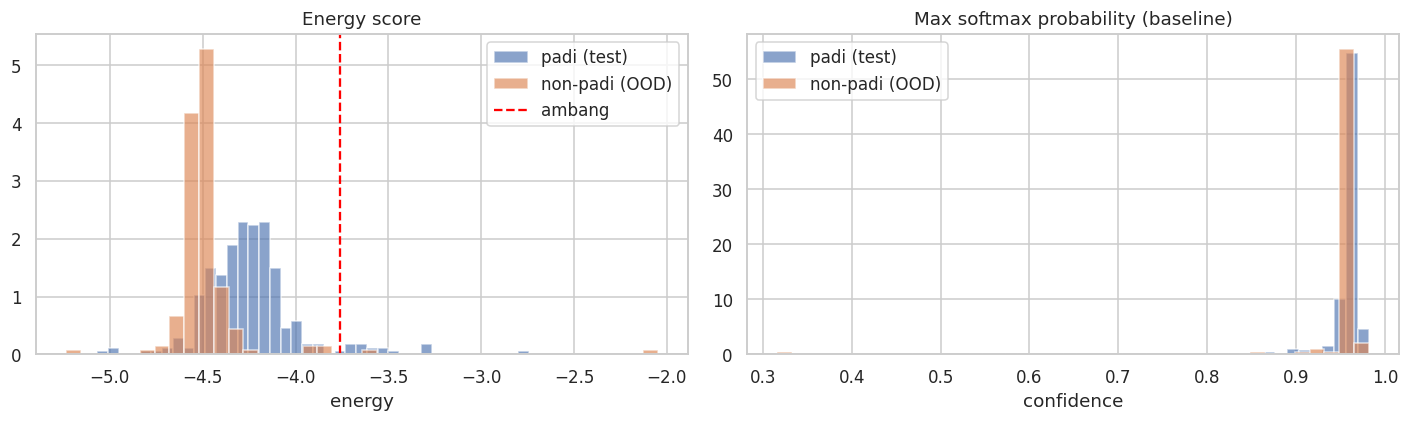

In [ ]:
# Gerbang OOD: export varian logits + kalibrasi ambang energy
from onnxruntime.quantization import quantize_dynamic, QuantType

class LogitsWrapper(nn.Module):
    def __init__(self, model, mean, std):
        super().__init__()
        self.model = model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))
    def forward(self, x):
        return self.model((x - self.mean) / self.std)

onnx_logits      = DEPLOY / "model_web_logits.onnx"
onnx_logits_int8 = DEPLOY / "model_web_logits_int8.onnx"

export_onnx(LogitsWrapper(export_model, MEAN, STD).eval(), onnx_logits, "logits")
quantize_dynamic(str(onnx_logits), str(onnx_logits_int8), weight_type=QuantType.QUInt8)
print(f"model_web_logits_int8.onnx: {onnx_logits_int8.stat().st_size/1e6:.1f} MB\n")

sess_gate = ort.InferenceSession(str(onnx_logits_int8), providers=["CPUExecutionProvider"])
GATE_IN = sess_gate.get_inputs()[0].name

def preprocess_np(path, size=IMG):
    # Preprocessing identik dengan eval_tf: resize sisi pendek -> center crop -> /255 -> NCHW
    img = Image.open(path).convert("RGB")
    short = int(size * 1.15)
    w, h = img.size
    s = short / min(w, h)
    img = img.resize((round(w * s), round(h * s)), Image.BILINEAR)
    l, t = (img.width - size) // 2, (img.height - size) // 2
    arr = np.asarray(img.crop((l, t, l + size, t + size)), dtype=np.float32) / 255.0
    return np.transpose(arr, (2, 0, 1))[None]

def energy_scores(paths, batch=16, desc="Energy"):
    E, MSP = [], []
    for i in tqdm(range(0, len(paths), batch), desc=desc, leave=False):
        x = np.concatenate([preprocess_np(p) for p in paths[i:i + batch]]).astype(np.float32)
        lg = sess_gate.run(None, {GATE_IN: x})[0]
        m = lg.max(axis=1, keepdims=True)
        lse = (m + np.log(np.exp(lg - m).sum(axis=1, keepdims=True))).ravel()
        E.append(-lse)                                                # energy = -logsumexp(logits)
        e = np.exp(lg - m)
        MSP.append((e / e.sum(axis=1, keepdims=True)).max(axis=1))    # baseline softmax
    return np.concatenate(E), np.concatenate(MSP)

val_rice  = val_df[val_df["label"] != NOT_RICE_LABEL]
N_CAL     = min(400, len(val_rice))
cal_paths = val_rice.sample(N_CAL, random_state=CONFIG["SEED"])["path"].tolist()
energy_val, msp_val = energy_scores(cal_paths, desc="Kalibrasi (val)")

ENERGY_THRESHOLD = float(np.percentile(energy_val, 95))   # 95% gambar sah harus tetap lolos
print(f"Energy pada {N_CAL} gambar val: median {np.median(energy_val):.3f} | "
      f"p95 {ENERGY_THRESHOLD:.3f} | maks {energy_val.max():.3f}")
print(f"AMBANG: tolak gambar bila energy > {ENERGY_THRESHOLD:.3f}\n")

# Harga yang dibayar: berapa gambar padi sah yang ikut tertolak
test_rice  = test_eval[test_eval["y_true"] != NOT_RICE_LABEL]
test_paths = test_rice.sample(min(300, len(test_rice)), random_state=1)["path"].tolist()
energy_test, msp_test = energy_scores(test_paths, desc="Cek (test)")
print(f"Gambar padi sah di test yang ikut tertolak: {(energy_test > ENERGY_THRESHOLD).mean()*100:.1f}%")

OOD_DIR = None

if OOD_DIR and Path(OOD_DIR).exists():
    ood_paths = [str(p) for p in Path(OOD_DIR).rglob("*") if p.suffix.lower() in IMG_EXT][:300]
elif NOT_RICE_LABEL in CLASSES:
    # Kelas ke-7 aktif -> gambar not_rice di TEST set langsung dipakai sebagai himpunan OOD
    ood_paths = test_eval[test_eval["y_true"] == NOT_RICE_LABEL]["path"].tolist()[:300]
    print(f"\n[INFO] memakai {len(ood_paths)} gambar not_rice dari test set sebagai himpunan OOD")
else:
    ood_paths = []

if ood_paths:
    from sklearn.metrics import roc_auc_score
    energy_ood, msp_ood = energy_scores(ood_paths, desc="OOD")

    y = np.r_[np.zeros(len(energy_test)), np.ones(len(energy_ood))]     # 1 = OOD
    auroc_energy = roc_auc_score(y, np.r_[energy_test, energy_ood])
    auroc_msp    = roc_auc_score(y, np.r_[-msp_test, -msp_ood])
    fpr95_energy = (energy_ood <= ENERGY_THRESHOLD).mean()
    fpr95_msp    = (msp_ood >= np.percentile(msp_val, 5)).mean()

    print(f"\nGambar OOD diuji: {len(ood_paths)}")
    print(f"  AUROC     - energy {auroc_energy:.4f} | softmax (baseline) {auroc_msp:.4f}")
    print(f"  FPR@95TPR - energy {fpr95_energy*100:.1f}% | softmax (baseline) {fpr95_msp*100:.1f}%")
    print( "  (FPR@95TPR = % gambar asing yang LOLOS; makin kecil makin baik)")

    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    ax[0].hist(energy_test, bins=40, alpha=.65, label="padi (test)", density=True)
    ax[0].hist(energy_ood, bins=40, alpha=.65, label="non-padi (OOD)", density=True)
    ax[0].axvline(ENERGY_THRESHOLD, ls="--", c="red", label="ambang")
    ax[0].set_title("Energy score"); ax[0].set_xlabel("energy"); ax[0].legend()
    ax[1].hist(msp_test, bins=40, alpha=.65, label="padi (test)", density=True)
    ax[1].hist(msp_ood, bins=40, alpha=.65, label="non-padi (OOD)", density=True)
    ax[1].set_title("Max softmax probability (baseline)"); ax[1].set_xlabel("confidence"); ax[1].legend()
    plt.tight_layout(); plt.savefig(OUT / "reports/figures/13_ood_gate.png", bbox_inches="tight"); plt.show()
else:
    print("\n[INFO] Tidak ada himpunan OOD (NOT_RICE_DIR & OOD_DIR kosong).")
    print("       Ambang tetap disimpan, tapi efektivitasnya belum terukur.")

In [56]:
# Artefak pendukung: label kelas dan config preprocessing
DISPLAY_NAME = {"blast": "Blast (Blas)", "blight": "Bacterial Leaf Blight (Hawar Daun Bakteri)",
                "brown_spot": "Brown Spot (Bercak Coklat)", "healthy": "Sehat",
                "scald": "Leaf Scald (Hangus Daun)", "tungro": "Tungro",
                "not_rice": "Bukan Daun Padi"}

labels = {"classes": CLASSES,
          "idx_to_label": {str(i): c for i, c in enumerate(CLASSES)},
          "label_to_idx": {c: i for i, c in enumerate(CLASSES)},
          "reject_labels": [NOT_RICE_LABEL] if NOT_RICE_LABEL in CLASSES else [],
          "display_name": {c: DISPLAY_NAME.get(c, c) for c in CLASSES}}
json.dump(labels, open(DEPLOY / "labels.json", "w"), indent=2, ensure_ascii=False)

preprocess_config = {
    "model_name": CONFIG["MODEL_NAME"],
    "input_size": [3, IMG, IMG],
    "input_layout": "NCHW",
    "color_space": "RGB",
    "resize_shorter_side_to": int(IMG * 1.15),
    "center_crop": IMG,
    "rescale": "bagi 255 -> rentang 0..1",
    "normalize": {"mean": MEAN, "std": STD,
                  "catatan": "model_web.onnx SUDAH menormalisasi di dalam graph; JANGAN normalisasi lagi. model.onnx BUTUH input ternormalisasi."},
    "output": {"model.onnx": "logits (perlu softmax)", "model_web.onnx": "probabilitas (softmax sudah di dalam)"},
    "io_names": globals().get("IO_NAMES", {}),
    "ood_gate": {
        "model": "model_web_logits_int8.onnx",
        "output": "logits mentah (BELUM softmax)",
        "energy_threshold": ENERGY_THRESHOLD,
        "rumus": "energy = -logsumexp(logits); TOLAK gambar bila energy > energy_threshold",
        "catatan": "Ambang dikalibrasi pada file INT8 di atas. Jangan dipakai untuk file model lain - kuantisasi menggeser skala logit."
    },
    "confidence_threshold": 0.80,
    "catatan_threshold": "Bila confidence < 0.80, kembalikan status 'uncertain' dan minta pengguna memotret ulang.",
    "test_metrics": metrics,
}
json.dump(preprocess_config, open(DEPLOY / "preprocess_config.json", "w"), indent=2, ensure_ascii=False)
print("Artefak pendukung tersimpan:", [p.name for p in DEPLOY.glob("*.json")])

Artefak pendukung tersimpan: ['labels.json', 'preprocess_config.json']


In [57]:
# Kode inference standalone untuk tim Fullstack
inference_code = '''
# inference.py - contoh inference standalone HealthyRice AI
# Output: klasifikasi + confidence saja. Pemetaan label -> rekomendasi penanganan
# dilakukan di sisi aplikasi web, bukan di sini.
# Dua mode: ONNX Runtime (disarankan untuk produksi) atau PyTorch TorchScript.
#   pip install onnxruntime pillow numpy
#   python inference.py --image daun.jpg

import json, argparse
from pathlib import Path
import numpy as np
from PIL import Image

BASE = Path(__file__).parent
CFG = json.load(open(BASE / "preprocess_config.json"))
LABELS = json.load(open(BASE / "labels.json"))
CLASSES = LABELS["classes"]
IMG = CFG["center_crop"]
THRESHOLD = CFG["confidence_threshold"]


def preprocess(image, normalize=False):
    # image: path / PIL.Image / bytes. Urutan WAJIB sama dengan training:
    # resize sisi terpendek -> center crop -> /255 -> (opsional) normalisasi -> NCHW
    if not isinstance(image, Image.Image):
        image = Image.open(image)
    img = image.convert("RGB")
    short = CFG["resize_shorter_side_to"]
    w, h = img.size
    scale = short / min(w, h)
    img = img.resize((round(w * scale), round(h * scale)), Image.BILINEAR)
    left, top = (img.width - IMG) // 2, (img.height - IMG) // 2
    img = img.crop((left, top, left + IMG, top + IMG))
    arr = np.asarray(img, dtype=np.float32) / 255.0
    if normalize:
        arr = (arr - np.array(CFG["normalize"]["mean"], np.float32)) / np.array(CFG["normalize"]["std"], np.float32)
    return np.transpose(arr, (2, 0, 1))[None]        # (1,3,H,W)


class RiceDiseaseONNX:
    # model_web.onnx: normalisasi + softmax sudah ada di dalam graph
    def __init__(self, model_path=BASE / "model_web.onnx"):
        import onnxruntime as ort
        so = ort.SessionOptions()
        so.intra_op_num_threads = 2
        self.sess = ort.InferenceSession(str(model_path), so, providers=["CPUExecutionProvider"])
        self.input_name = self.sess.get_inputs()[0].name

    def predict(self, image, top_k=3):
        x = preprocess(image, normalize=False)
        probs = self.sess.run(None, {self.input_name: x.astype(np.float32)})[0][0]
        order = np.argsort(-probs)[:top_k]
        top = [{"label": CLASSES[i],
                "display_name": LABELS["display_name"][CLASSES[i]],
                "confidence": round(float(probs[i]), 4)} for i in order]
        best = top[0]
        uncertain = best["confidence"] < THRESHOLD
        return {
            "prediction": best["label"],
            "display_name": best["display_name"],
            "confidence": best["confidence"],
            "is_uncertain": uncertain,
            "message": ("Model kurang yakin. Mohon foto ulang daun dari jarak dekat dengan pencahayaan cukup."
                        if uncertain else "Deteksi berhasil."),
            "top_k": top,
        }


class RiceDiseaseTorch:
    # Alternatif TorchScript (butuh input TERNORMALISASI dan softmax manual)
    def __init__(self, model_path=BASE / "model_torchscript.pt"):
        import torch
        self.torch = torch
        self.model = torch.jit.load(str(model_path), map_location="cpu").eval()

    def predict(self, image, top_k=3):
        x = self.torch.from_numpy(preprocess(image, normalize=True).astype(np.float32))
        with self.torch.no_grad():
            probs = self.torch.softmax(self.model(x), 1)[0].numpy()
        order = np.argsort(-probs)[:top_k]
        return {"prediction": CLASSES[order[0]], "confidence": round(float(probs[order[0]]), 4),
                "top_k": [{"label": CLASSES[i], "confidence": round(float(probs[i]), 4)} for i in order]}


class RiceDiseaseGated:
    # DIPAKAI PRODUKSI. Memakai model logits + energy score, sehingga bisa MENOLAK
    # gambar yang bukan daun padi (rumput, lukisan, objek acak) alih-alih menebak.
    def __init__(self, model_path=BASE / "model_web_logits_int8.onnx"):
        import onnxruntime as ort
        so = ort.SessionOptions()
        so.intra_op_num_threads = 2
        self.sess = ort.InferenceSession(str(model_path), so, providers=["CPUExecutionProvider"])
        self.input_name = self.sess.get_inputs()[0].name
        self.energy_threshold = CFG.get("ood_gate", {}).get("energy_threshold")

    def predict(self, image, top_k=3):
        x = preprocess(image, normalize=False).astype(np.float32)
        logits = self.sess.run(None, {self.input_name: x})[0][0]

        m = float(logits.max())
        energy = -(m + float(np.log(np.exp(logits - m).sum())))    # makin besar = makin asing
        e = np.exp(logits - m)
        probs = e / e.sum()

        order = np.argsort(-probs)[:top_k]
        top = [{"label": CLASSES[i],
                "display_name": LABELS["display_name"][CLASSES[i]],
                "confidence": round(float(probs[i]), 4)} for i in order]
        best = top[0]

        # Dua lapis penolakan:
        #   (1) prediksi jatuh ke kelas not_rice (bila model dilatih 7 kelas)
        #   (2) energy score, untuk objek asing yang tidak terwakili kelas not_rice
        rejected = best["label"] in LABELS.get("reject_labels", [])
        if self.energy_threshold is not None and energy > self.energy_threshold:
            rejected = True
        uncertain = best["confidence"] < THRESHOLD

        if rejected:
            return {"prediction": None, "display_name": None, "confidence": best["confidence"],
                    "is_out_of_distribution": True, "is_uncertain": True,
                    "energy": round(energy, 3), "energy_threshold": self.energy_threshold,
                    "message": "Gambar tidak dikenali sebagai daun padi. Mohon foto daun padi dari jarak dekat.",
                    "top_k": top}

        return {"prediction": best["label"], "display_name": best["display_name"],
                "confidence": best["confidence"],
                "is_out_of_distribution": False, "is_uncertain": uncertain,
                "energy": round(energy, 3), "energy_threshold": self.energy_threshold,
                "message": ("Model kurang yakin. Mohon foto ulang daun dari jarak dekat dengan pencahayaan cukup."
                            if uncertain else "Deteksi berhasil."),
                "top_k": top}


if __name__ == "__main__":
    ap = argparse.ArgumentParser()
    ap.add_argument("--image", required=True)
    ap.add_argument("--backend", default="gated", choices=["gated", "onnx", "torch"])
    a = ap.parse_args()
    clf = {"gated": RiceDiseaseGated, "onnx": RiceDiseaseONNX, "torch": RiceDiseaseTorch}[a.backend]()
    print(json.dumps(clf.predict(a.image), indent=2, ensure_ascii=False))
'''

(DEPLOY / "inference.py").write_text(inference_code.strip() + "\n")
(DEPLOY / "requirements.txt").write_text("onnxruntime>=1.17.0\npillow>=10.0.0\nnumpy>=1.24.0\n")
print("inference.py & requirements.txt tersimpan.")

# Uji langsung kode inference tersebut pada gambar test
sys.path.insert(0, str(DEPLOY))
import importlib, inference as inf_mod
importlib.reload(inf_mod)

clf = inf_mod.RiceDiseaseONNX(DEPLOY / "model_web.onnx")
sample = test_eval.sample(3, random_state=1)
for _, r in sample.iterrows():
    out = clf.predict(r["path"])
    print(f"\nFile   : {Path(r['path']).name}  (label asli: {r['y_true']})")
    print(f"Prediksi: {out['prediction']} | confidence {out['confidence']:.3f} | uncertain={out['is_uncertain']}")
    print(f"Top-3  : {[(t['label'], t['confidence']) for t in out['top_k']]}")

# Demo gerbang OOD pada file INT8 yang akan dipakai produksi
clf_gated = inf_mod.RiceDiseaseGated(DEPLOY / "model_web_logits_int8.onnx")
r = test_eval.sample(1, random_state=7).iloc[0]
g = clf_gated.predict(r["path"])
print(f"\n[gated] {Path(r['path']).name} (asli: {r['y_true']}) -> {g['prediction']} "
      f"| conf {g['confidence']:.3f} | energy {g['energy']:.2f} (ambang {g['energy_threshold']:.2f}) "
      f"| ditolak={g['is_out_of_distribution']}")

t0 = time.time()
for _ in range(10):
    clf.predict(sample.iloc[0]["path"])
print(f"\nLatensi rata-rata end-to-end (CPU, termasuk preprocessing): {(time.time()-t0)/10*1000:.1f} ms/gambar")

inference.py & requirements.txt tersimpan.

File   : BLB_0404.jpg  (label asli: blight)
Prediksi: blight | confidence 0.962 | uncertain=False
Top-3  : [('blight', 0.9615), ('blast', 0.007), ('not_rice', 0.0066)]

File   : HL_339.jpg  (label asli: healthy)
Prediksi: healthy | confidence 0.947 | uncertain=False
Top-3  : [('healthy', 0.947), ('blast', 0.0169), ('tungro', 0.0098)]

File   : TUNGRO3_263.JPG  (label asli: tungro)
Prediksi: tungro | confidence 0.963 | uncertain=False
Top-3  : [('tungro', 0.9629), ('healthy', 0.0065), ('blight', 0.0063)]

[gated] IMG_20231014_172324.jpg (asli: blight) -> blight | conf 0.941 | energy -4.07 (ambang -3.76) | ditolak=False

Latensi rata-rata end-to-end (CPU, termasuk preprocessing): 82.9 ms/gambar


In [58]:
# Model card
model_card = f'''# HealthyRice AI - Model Card

## Ringkasan
- Arsitektur      : {CONFIG["MODEL_NAME"]} (timm, transfer learning)
- Tugas           : klasifikasi {NUM_CLASSES} kelas (penyakit daun padi{" + kelas penolak not_rice" if NOT_RICE_LABEL in CLASSES else ""})
- Kelas           : {", ".join(CLASSES)}
- Input           : RGB {IMG}x{IMG}, NCHW, rentang 0..1 (model_web.onnx) / ternormalisasi (model.onnx)
- Tanggal training: {time.strftime("%Y-%m-%d")}

## Data
- Total gambar setelah cleaning : {len(df)}
- Split (group-aware, stratified): train {len(train_df)} / val {len(val_df)} / test {len(test_df)}
- Anti-leakage: gambar near-duplicate (pHash Hamming <= {CONFIG["PHASH_DUP_THRESHOLD"]}) dikunci dalam group yang sama sehingga tidak tersebar antar split.

## Performa (test set)
| Metrik | Nilai |
|---|---|
| Accuracy | {metrics["accuracy"]:.4f} |
| Macro F1 | {metrics["macro_f1"]:.4f} |
| Macro Precision | {metrics["macro_precision"]:.4f} |
| Macro Recall | {metrics["macro_recall"]:.4f} |

## Keterbatasan
- Dilatih pada dataset publik multi-source, performa pada foto HP di sawah nyata bisa lebih rendah (domain gap).
- Model tidak mengenali kondisi di luar {NUM_CLASSES} kelas (hama, defisiensi hara) - gunakan gerbang energy + confidence threshold {preprocess_config["confidence_threshold"]}.
- Ruang lingkup model hanya klasifikasi gambar (label + confidence). Rekomendasi penanganan dikelola aplikasi web.

## Cara pakai
Lihat `inference.py` dan `preprocess_config.json`.
'''
(DEPLOY / "MODEL_CARD.md").write_text(model_card)

zip_path = OUT / "healthyrice_deploy.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for f in sorted(DEPLOY.glob("*")):
        if f.is_file():
            z.write(f, f.name)

print("ISI FOLDER DEPLOY")
for f in sorted(DEPLOY.glob("*")):
    print(f"  {f.name:28s} {f.stat().st_size/1e6:8.2f} MB")
print(f"\nPaket ZIP: {zip_path} ({zip_path.stat().st_size/1e6:.2f} MB)")
print("\nStruktur output lengkap:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(OUT))

ISI FOLDER DEPLOY
  MODEL_CARD.md                    0.00 MB
  __pycache__                      0.00 MB
  inference.py                     0.01 MB
  labels.json                      0.00 MB
  model.onnx                     111.60 MB
  model_state_dict.pth           111.56 MB
  model_torchscript.pt           111.55 MB
  model_web.onnx                 111.62 MB
  model_web_fp16.onnx             55.92 MB
  model_web_int8.onnx             28.48 MB
  model_web_logits.onnx          111.62 MB
  model_web_logits_int8.onnx      28.48 MB
  preprocess_config.json           0.00 MB
  requirements.txt                 0.00 MB

Paket ZIP: /kaggle/working/artifacts/healthyrice_deploy.zip (607.47 MB)

Struktur output lengkap:
   checkpoints/best_model.pth
   deploy/MODEL_CARD.md
   deploy/__pycache__/inference.cpython-312.pyc
   deploy/inference.py
   deploy/labels.json
   deploy/model.onnx
   deploy/model_state_dict.pth
   deploy/model_torchscript.pt
   deploy/model_web.onnx
   deploy/model_web_fp16.o